# Build an LLM from Scratch - Complete Tutorial

**Author:** [Adam Shedivy](https://github.com/ajshedivy)

**Based on:** [Build a Large Language Model (From Scratch)](https://www.manning.com/books/build-a-large-language-model-from-scratch) by [Sebastian Raschka](https://sebastianraschka.com)

---

## 🎯 Learning Objectives

This comprehensive notebook guides you through building a Large Language Model from the ground up, covering every essential component and concept. By the end, you'll have both theoretical understanding and practical implementation skills for modern LLMs.

## 📚 What You'll Build & Learn

### **1. Text Data Processing**
- **Tokenization:** Converting raw text into model-processable tokens
- **Embeddings:** Transforming discrete tokens into continuous vector representations
- **Byte-Pair Encoding (BPE):** Handling out-of-vocabulary words efficiently
- **Data Loading:** Creating training datasets with sliding window techniques

### **2. Attention Mechanisms**
- **Contextual Understanding:** How models focus on relevant information
- **Query-Key-Value Systems:** The mathematical foundation of attention
- **Multi-Head Attention:** Parallel processing of different relationship types
- **Visualization Tools:** Interactive exploration of attention patterns

### **3. GPT Architecture Implementation**
- **Layer Normalization:** Stabilizing deep network training
- **Feed-Forward Networks:** Adding model capacity and non-linearity
- **Residual Connections:** Enabling deep network gradient flow
- **Transformer Blocks:** Assembling complete processing units

### **4. Model Training Pipeline**
- **Loss Functions:** Cross-entropy and perplexity for language modeling
- **Training Loops:** End-to-end optimization with monitoring
- **Validation:** Detecting overfitting and measuring generalization
- **Performance Analysis:** Understanding training dynamics

### **5. Advanced Text Generation**
- **Temperature Scaling:** Controlling output randomness and creativity
- **Top-k Sampling:** Balancing diversity with quality
- **Decoding Strategies:** Production-ready text generation techniques
- **Interactive Generation:** Customizable output control

### **6. Production Integration**
- **Pretrained Weights:** Loading state-of-the-art OpenAI GPT-2 models
- **Performance Comparison:** Small-scale vs. massive-scale training
- **Real-world Applications:** Using trained models for practical tasks

## 🎓 Skills You'll Gain

✅ **Deep Learning Fundamentals:** Attention mechanisms, training pipelines, optimization  
✅ **NLP Expertise:** Tokenization, language modeling, text generation  
✅ **PyTorch Mastery:** Model implementation, training, and deployment  
✅ **Production Skills:** Working with pretrained models and generation control  
✅ **Research Understanding:** Foundation for exploring cutting-edge techniques

## 📖 Original Source & Citation

This tutorial is adapted from Sebastian Raschka's excellent book:

```bibtex
@book{build-llms-from-scratch-book,
  author       = {Sebastian Raschka},
  title        = {Build A Large Language Model (From Scratch)},
  publisher    = {Manning},
  year         = {2024},
  isbn         = {978-1633437166},
  url          = {https://www.manning.com/books/build-a-large-language-model-from-scratch},
  github       = {https://github.com/rasbt/LLMs-from-scratch}
}
```

**Code Repository:** [https://github.com/rasbt/LLMs-from-scratch](https://github.com/rasbt/LLMs-from-scratch)

---

## 🚀 Ready to Build Your LLM?

This notebook combines theory with hands-on implementation, taking you from basic concepts to production-ready systems. Each section builds naturally on the previous, with clear explanations, interactive examples, and practical applications.

**Let's start building the future of AI!** 🌟

## Citation

```txt
@book{build-llms-from-scratch-book,
  author       = {Sebastian Raschka},
  title        = {Build A Large Language Model (From Scratch)},
  publisher    = {Manning},
  year         = {2024},
  isbn         = {978-1633437166},
  url          = {https://www.manning.com/books/build-a-large-language-model-from-scratch},
  github       = {https://github.com/rasbt/LLMs-from-scratch}
}
```

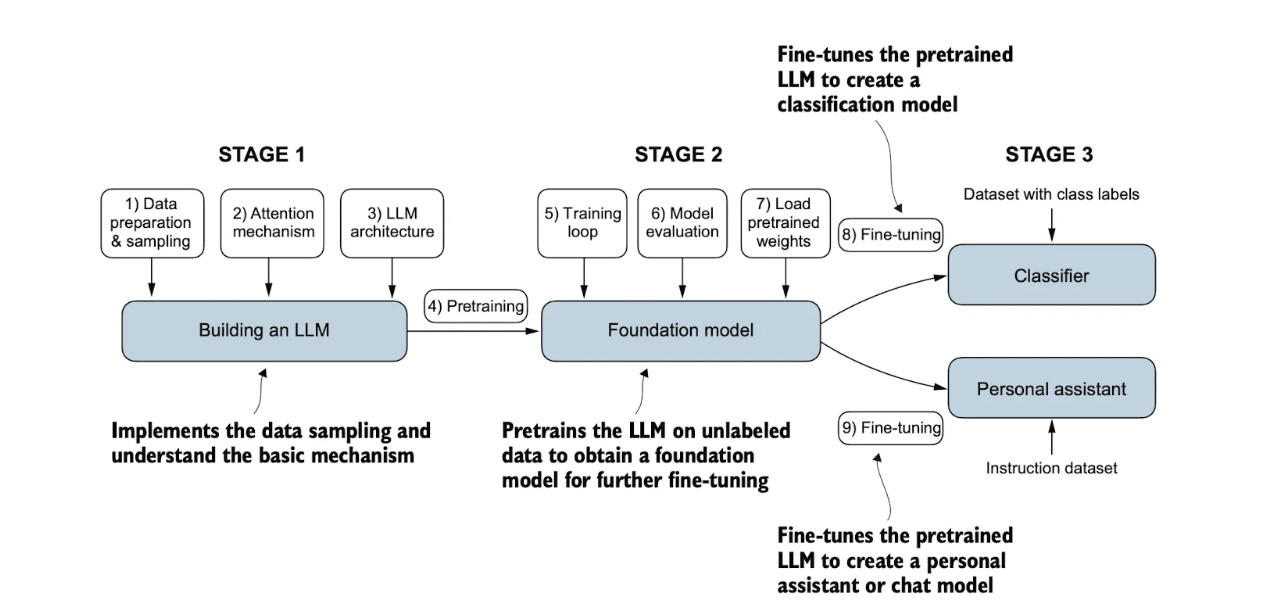

# 1. Working with Text Data

## Understanding Embeddings

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/02.webp" width="700px">

**Key concepts:**
- Deep neural network models (including LLMs) cannot process raw text directly
- Text must be converted to numerical representation through **embedding**
- Core idea: mapping from discrete objects (words, images, documents) to points in a continuous vector space
- LLMs work with **embeddings** in high-dimensional spaces (thousands of dimensions)

### Visualizing Embeddings

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/03.webp" width="500px">

Let's explore how word embeddings work by finding words similar to "tower":

#### Code Example: Finding Similar Words

In [2]:
import gensim.downloader

# download small embedding model
model = gensim.downloader.load('glove-wiki-gigaword-50')

# vectore embedding for 'tower'
model['tower']

array([ 1.1474e+00,  1.1811e+00,  7.4556e-01, -5.9101e-02,  5.0499e-01,
       -7.0449e-01, -3.2136e-01, -4.5390e-01, -4.5763e-01, -7.5341e-01,
       -3.3511e-01, -2.4975e-02, -5.0192e-01,  6.3773e-01, -8.3059e-01,
        8.3565e-01, -2.4701e-01,  3.2421e-01, -1.1103e+00, -2.1335e-02,
        6.8717e-01, -3.9340e-01, -1.6390e+00, -5.0493e-01, -1.6684e-01,
       -6.7649e-01, -3.1798e-01,  8.8503e-01, -3.1552e-02, -1.5608e-01,
        1.9805e+00, -1.1870e+00,  8.3342e-01, -1.8369e-01, -2.6691e-01,
        1.1619e-01,  1.1023e+00, -3.5937e-01,  2.5015e-02, -4.0615e-02,
        3.0681e-01, -4.1076e-01,  8.4586e-02,  2.2475e-01, -5.0955e-01,
        6.5819e-01, -1.2432e-01, -1.4039e+00,  1.6178e-04, -5.2529e-01],
      dtype=float32)

In [3]:
# select the words "most similar" to tower
similar_words = model.most_similar('tower')
similar_words

[('towers', 0.877095639705658),
 ('gate', 0.7934194803237915),
 ('building', 0.7872828841209412),
 ('built', 0.7803678512573242),
 ('roof', 0.7780845165252686),
 ('skyscraper', 0.7487501502037048),
 ('constructed', 0.7471458911895752),
 ('dome', 0.7415344715118408),
 ('facade', 0.7309736013412476),
 ('entrance', 0.7280209064483643)]

➡  Loading pre-trained model: 'glove-wiki-gigaword-50' …
➡  PCA explains 62.2% of the variance in 3 components.
🎯 Creating interactive visualizations...
1. Basic 3D scatter plot


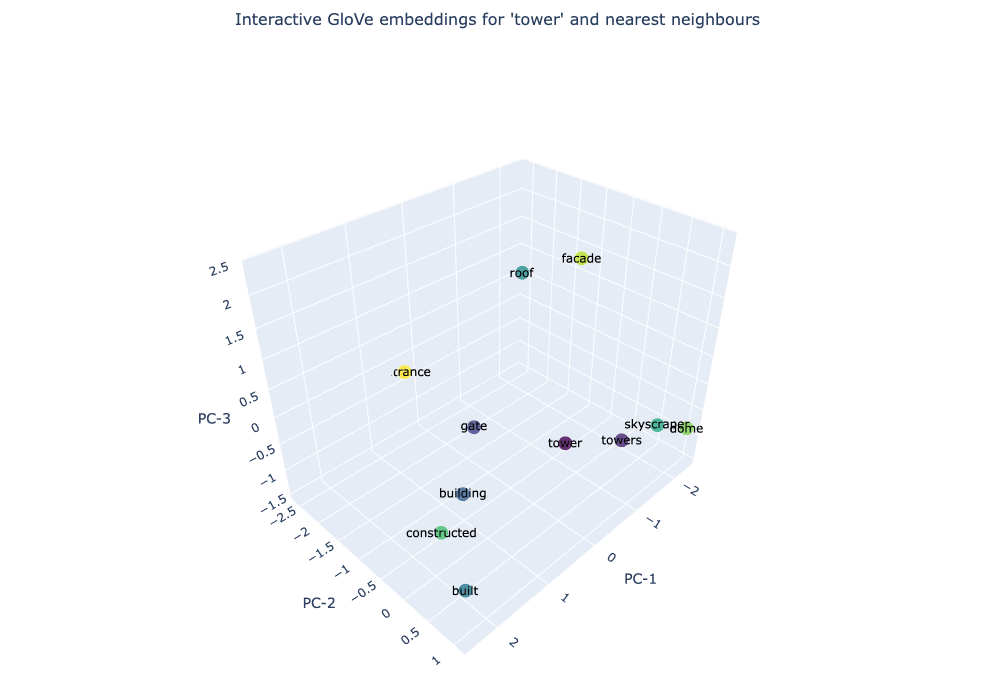

2. Direction vectors visualization


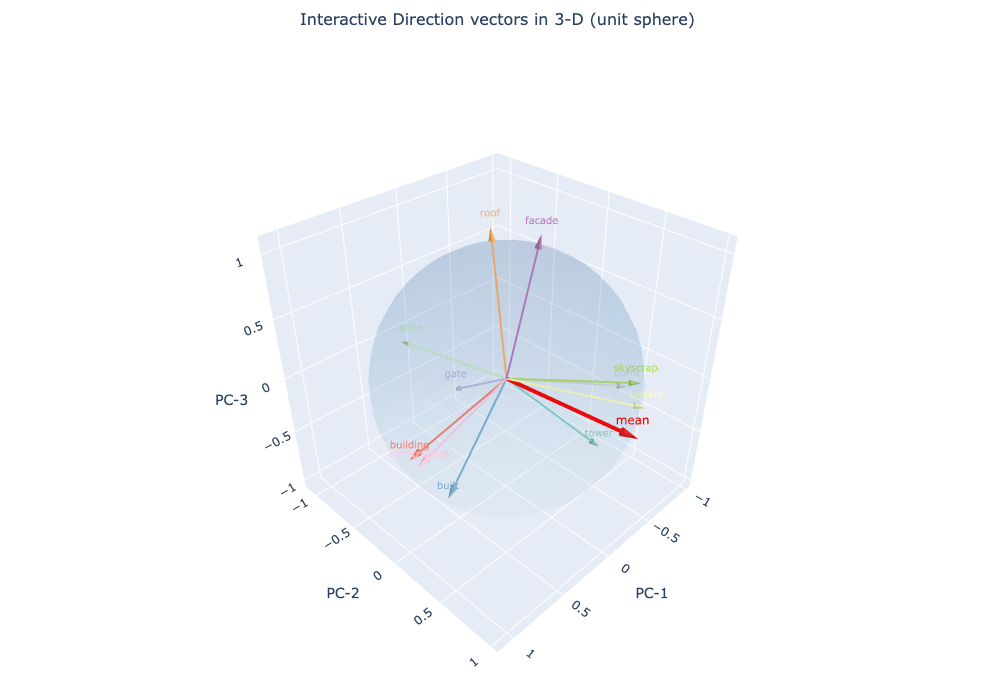

In [4]:
from utils import load_glove, most_similar, reduce_to_3d, plot_3d_interactive, plot_directions_interactive

# Load model and create interactive visualizations
model = load_glove(dim=50)
words, vecs = most_similar(model, "tower", topn=10)
coords = reduce_to_3d(vecs)

print("🎯 Creating interactive visualizations...")
print("1. Basic 3D scatter plot")
plot_3d_interactive(words, coords)

print("2. Direction vectors visualization")
plot_directions_interactive(words, coords)

#### Analysis: Visualizing Word Relationships

**Key insights from the visualization:**
- We reduced dimensionality from 50 down to 3 using PCA
- The 3 axes represent the first 3 principal components - the 3 most important dimensions of the data
- Think of it as squashing a 50-dimensional space down to 3 dimensions while preserving the most important relationships
- **Main principle**: similar words have similar directions in embedding space

## Tokenizing Text Data

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/04.webp" width="500px">

**What is tokenization?**
- Breaking down text into smaller pieces (words or subwords)
- Essential step for preparing text data for LLMs
- Converts raw text into a format processable by neural networks

### Loading the Dataset

We'll use [The Verdict by Edith Wharton](https://en.wikisource.org/wiki/The_Verdict), a public domain short story, for our tokenization examples:

In [5]:
import os
import urllib.request

if not os.path.exists("the-verdict.txt"):
    url = ("https://raw.githubusercontent.com/rasbt/"
           "LLMs-from-scratch/main/ch02/01_main-chapter-code/"
           "the-verdict.txt")
    file_path = "the-verdict.txt"
    urllib.request.urlretrieve(url, file_path)

In [6]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
print("Total number of character:", len(raw_text))
print(raw_text[:99])

Total number of character: 20479
I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


### Building a Simple Tokenizer

Let's create a tokenizer that splits text into words and handles punctuation.

**Step 1: Basic whitespace splitting**

In [7]:
import re

text = "Hello, world. This, is a test."
result = re.split(r'(\s)', text)

print(result)

['Hello,', ' ', 'world.', ' ', 'This,', ' ', 'is', ' ', 'a', ' ', 'test.']


**Step 2: Handling punctuation**

We need to handle punctuation like commas and periods separately:

In [8]:
result = re.split(r'([,.]|\s)', text)

print(result)

['Hello', ',', '', ' ', 'world', '.', '', ' ', 'This', ',', '', ' ', 'is', ' ', 'a', ' ', 'test', '.', '']


**Step 3: Cleaning empty tokens**

Remove empty strings from our token list:

In [9]:
# Strip whitespace from each item and then filter out any empty strings.
result = [item for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'This', ',', 'is', 'a', 'test', '.']


**Step 4: Extended special character handling**

Let's handle additional special characters:

In [10]:
text = "Hello, world. Is this-- a test?"

result = re.split(r'([,.:;?_!"()\']|--|\s)', text)
result = [item.strip() for item in result if item.strip()]
print(result)

['Hello', ',', 'world', '.', 'Is', 'this', '--', 'a', 'test', '?']


### Applying Tokenization to Our Dataset

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/05.webp" width="500px">

Let's apply our tokenizer to the full text:

In [11]:
preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', raw_text)
preprocessed = [item.strip() for item in preprocessed if item.strip()]
print(preprocessed[:30])

['I', 'HAD', 'always', 'thought', 'Jack', 'Gisburn', 'rather', 'a', 'cheap', 'genius', '--', 'though', 'a', 'good', 'fellow', 'enough', '--', 'so', 'it', 'was', 'no', 'great', 'surprise', 'to', 'me', 'to', 'hear', 'that', ',', 'in']


**Token count analysis:**

In [12]:
print(len(preprocessed))

4690


## Converting Tokens to Token IDs

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/06.webp" width="500px">

**Purpose:** Convert text tokens into numerical IDs that can be processed by embedding layers.

**Step 1: Build vocabulary**
Create a vocabulary from all unique tokens:

In [14]:
# sort out duplicates
all_words = sorted(set(preprocessed))
vocab_size = len(all_words)

print(vocab_size)

1130


**Step 2: Create token-to-ID mapping**
First 50 entries of our vocabulary:

In [15]:
vocab = {token:integer for integer,token in enumerate(all_words)}

for i, item in enumerate(vocab.items()):
    print(item)
    if i >= 50:
        break

('!', 0)
('"', 1)
("'", 2)
('(', 3)
(')', 4)
(',', 5)
('--', 6)
('.', 7)
(':', 8)
(';', 9)
('?', 10)
('A', 11)
('Ah', 12)
('Among', 13)
('And', 14)
('Are', 15)
('Arrt', 16)
('As', 17)
('At', 18)
('Be', 19)
('Begin', 20)
('Burlington', 21)
('But', 22)
('By', 23)
('Carlo', 24)
('Chicago', 25)
('Claude', 26)
('Come', 27)
('Croft', 28)
('Destroyed', 29)
('Devonshire', 30)
('Don', 31)
('Dubarry', 32)
('Emperors', 33)
('Florence', 34)
('For', 35)
('Gallery', 36)
('Gideon', 37)
('Gisburn', 38)
('Gisburns', 39)
('Grafton', 40)
('Greek', 41)
('Grindle', 42)
('Grindles', 43)
('HAD', 44)
('Had', 45)
('Hang', 46)
('Has', 47)
('He', 48)
('Her', 49)
('Hermia', 50)


### Tokenization Example

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/07.webp?123" width="700px">

Here's how the tokenization process works step by step:

### Complete Tokenizer Implementation

Let's create a complete tokenizer class with encoding and decoding capabilities:

**Features:**
- `encode`: converts text to token IDs
- `decode`: converts token IDs back to text

In [16]:
class SimpleTokenizerV1:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = {i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
                                
        preprocessed = [
            item.strip() for item in preprocessed if item.strip()
        ]
        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
        
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.?!"()\'])', r'\1', text)
        return text

#### Testing Our Tokenizer

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/08.webp?123" width="500px">

Let's test the encode and decode functionality:

In [17]:
tokenizer = SimpleTokenizerV1(vocab)

text = """"It's the last he painted, you know," 
           Mrs. Gisburn said with pardonable pride."""
ids = tokenizer.encode(text)
print(ids)
print(tokenizer.decode(ids))
print(tokenizer.decode(tokenizer.encode(text)))

[1, 56, 2, 850, 988, 602, 533, 746, 5, 1126, 596, 5, 1, 67, 7, 38, 851, 1108, 754, 793, 7]
" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.
" It' s the last he painted, you know," Mrs. Gisburn said with pardonable pride.


## Adding Special Tokens

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/09.webp?123" width="500px">

**Why special tokens?**
LLMs use special tokens to provide additional context:
- `[BOS]` (beginning of sequence) - marks text start
- `[EOS]` (end of sequence) - marks text end
- `[PAD]` (padding) - for batch processing
- `[UNK]` (unknown) - for out-of-vocabulary words

**GPT-2 simplification:**
- Uses only `<|endoftext|>` token (similar to `[EOS]`)
- Also used for padding and between different text sources
- No `[UNK]` needed due to Byte-Pair Encoding (BPE)

### Using Special Tokens Between Text Sources

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/10.webp" width="500px">

Example of using `<|endoftext|>` to separate different text sources:

#### Handling Unknown Words

Let's test what happens with out-of-vocabulary words:

In [18]:
tokenizer = SimpleTokenizerV1(vocab)

text = "Hello, do you like tea. Is this-- a test?"

tokenizer.encode(text)

KeyError: 'Hello'

#### Problem Analysis

The error occurs because "Hello" isn't in our vocabulary. We need to:
1. Add special tokens like `<|unk|>` for unknown words
2. Add `<|endoftext|>` for text separation

In [19]:
all_tokens = sorted(list(set(preprocessed)))
all_tokens.extend(["<|endoftext|>", "<|unk|>"])

vocab = {token:integer for integer,token in enumerate(all_tokens)}
print(f"updated vocab length: {len(vocab.items())}")
for i, item in enumerate(list(vocab.items())[-5:]):
    print(item)

updated vocab length: 1132
('younger', 1127)
('your', 1128)
('yourself', 1129)
('<|endoftext|>', 1130)
('<|unk|>', 1131)


#### Enhanced Tokenizer with Special Tokens

Let's create an improved tokenizer that handles unknown words:

In [20]:
class SimpleTokenizerV2:
    def __init__(self, vocab):
        self.str_to_int = vocab
        self.int_to_str = { i:s for s,i in vocab.items()}
    
    def encode(self, text):
        preprocessed = re.split(r'([,.:;?_!"()\']|--|\s)', text)
        preprocessed = [item.strip() for item in preprocessed if item.strip()]
        preprocessed = [
            item if item in self.str_to_int 
            else "<|unk|>" for item in preprocessed
        ]

        ids = [self.str_to_int[s] for s in preprocessed]
        return ids
        
    def decode(self, ids):
        text = " ".join([self.int_to_str[i] for i in ids])
        # Replace spaces before the specified punctuations
        text = re.sub(r'\s+([,.:;?!"()\'])', r'\1', text)
        return text

In [21]:
tokenizer = SimpleTokenizerV2(vocab)

text1 = "Hello, do you like tea?"
text2 = "In the sunlit terraces of the palace."

text = " <|endoftext|> ".join((text1, text2))

print(text)

Hello, do you like tea? <|endoftext|> In the sunlit terraces of the palace.


In [27]:
ids = tokenizer.encode(text)
print(f"ids: {ids}")
print(f"tokenized text: {tokenizer.decode(ids)}")

ids: [1131, 5, 355, 1126, 628, 975, 10, 1130, 55, 988, 956, 984, 722, 988, 1131, 7]
tokenized text: <|unk|>, do you like tea? <|endoftext|> In the sunlit terraces of the <|unk|>.


## Byte-Pair Encoding (BPE)

**Why BPE?**
- GPT-2 uses Byte-Pair Encoding as its tokenizer
- Handles out-of-vocabulary words by breaking them into smaller subword units
- Can process any word, even if not in the predefined vocabulary

**Example:** If "unfamiliarword" isn't in vocabulary, BPE might tokenize it as `["unfam", "iliar", "word"]`

### Code Example: Using GPT-2's BPE Tokenizer

In [28]:
import importlib
import tiktoken

print("tiktoken version:", importlib.metadata.version("tiktoken"))

# load tokenizer
tokenizer = tiktoken.get_encoding("gpt2")

text = (
    "Hello, do you like tea? <|endoftext|> In the sunlit terraces"
     "of someunknownPlace."
)

# encode text
integers = tokenizer.encode(text, allowed_special={"<|endoftext|>"})
print(integers)

# decode text
strings = tokenizer.decode(integers)
print(strings)

tiktoken version: 0.9.0
[15496, 11, 466, 345, 588, 8887, 30, 220, 50256, 554, 262, 4252, 18250, 8812, 2114, 1659, 617, 34680, 27271, 13]
Hello, do you like tea? <|endoftext|> In the sunlit terracesof someunknownPlace.


#### BPE Advantage

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/11.webp" width="500px">

BPE tokenizers break down unknown words into subword units, enabling models to handle any text input.

## Data Sampling with Sliding Windows

**Training concept:**
- LLMs generate one word at a time
- Training data must be prepared for next-word prediction
- Use sliding windows to create input-target pairs

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/12.webp" width="700px">

In [31]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()

enc_text = tokenizer.encode(raw_text)
print(len(enc_text))

enc_sample = enc_text[50:]
context_size = 4

x = enc_sample[:context_size]
y = enc_sample[1:context_size+1]

print(f"x: {x}")
print(f"y:      {y}")

5145
x: [290, 4920, 2241, 287]
y:      [4920, 2241, 287, 257]


### Understanding Input-Target Relationships

**Key principle:** Targets are inputs shifted by one position
- **Input:** "The cat sat on the"
- **Target:** "cat sat on the mat"

This teaches the model to predict the next word in sequence.

In [32]:
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(context, "---->", desired)

print('--------------------------------------------')
for i in range(1, context_size+1):
    context = enc_sample[:i]
    desired = enc_sample[i]

    print(tokenizer.decode(context), "---->", tokenizer.decode([desired]))

[290] ----> 4920
[290, 4920] ----> 2241
[290, 4920, 2241] ----> 287
[290, 4920, 2241, 287] ----> 257
--------------------------------------------
 and ---->  established
 and established ---->  himself
 and established himself ---->  in
 and established himself in ---->  a


### Implementing the Data Loader

Let's create a data loader that handles the sliding window approach for training:

In [33]:
import torch
print("PyTorch version:", torch.__version__)

from torch.utils.data import Dataset, DataLoader


class GPTDatasetV1(Dataset):
    def __init__(self, txt, tokenizer, max_length, stride):
        self.input_ids = []
        self.target_ids = []

        # Tokenize the entire text
        token_ids = tokenizer.encode(txt, allowed_special={"<|endoftext|>"})
        assert len(token_ids) > max_length, "Number of tokenized inputs must at least be equal to max_length+1"

        # Use a sliding window to chunk the book into overlapping sequences of max_length
        for i in range(0, len(token_ids) - max_length, stride):
            input_chunk = token_ids[i:i + max_length]
            target_chunk = token_ids[i + 1: i + max_length + 1]
            self.input_ids.append(torch.tensor(input_chunk))
            self.target_ids.append(torch.tensor(target_chunk))

    def __len__(self):
        return len(self.input_ids)

    def __getitem__(self, idx):
        return self.input_ids[idx], self.target_ids[idx]

PyTorch version: 2.7.0


In [34]:
def create_dataloader_v1(txt, batch_size=4, max_length=256, 
                         stride=128, shuffle=True, drop_last=True,
                         num_workers=0):

    # Initialize the tokenizer
    tokenizer = tiktoken.get_encoding("gpt2")

    # Create dataset
    dataset = GPTDatasetV1(txt, tokenizer, max_length, stride)

    # Create dataloader
    dataloader = DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        drop_last=drop_last,
        num_workers=num_workers
    )

    return dataloader

#### Testing the Data Loader

Let's test with a small context size to see how the sliding window works:

In [35]:
with open("the-verdict.txt", "r", encoding="utf-8") as f:
    raw_text = f.read()
    
dataloader = create_dataloader_v1(
    raw_text, batch_size=1, max_length=4, stride=1, shuffle=False
)

data_iter = iter(dataloader)
first_batch = next(data_iter)
print(first_batch)

second_batch = next(data_iter)
print(second_batch)

[tensor([[  40,  367, 2885, 1464]]), tensor([[ 367, 2885, 1464, 1807]])]
[tensor([[ 367, 2885, 1464, 1807]]), tensor([[2885, 1464, 1807, 3619]])]


#### Stride Configuration Example

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/14.webp" width="500px">

When stride equals context length, we get non-overlapping windows.

## Token Embeddings

**Final step:** Convert token IDs to continuous vector representations

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/15.webp" width="500px">

**Key concepts:**
- Embedding layers are part of the LLM and are learned during training
- They map discrete token IDs to continuous vector space
- More efficient than one-hot encoding + matrix multiplication

### Example: Creating Token Embeddings

Let's create a simple example with 4 input tokens:

In [36]:
input_ids = torch.tensor([2, 3, 5, 1])

#### Creating the Embedding Layer

For demonstration, let's use a vocabulary of 6 words with 3-dimensional embeddings:

In [37]:
vocab_size = 6
output_dim = 3

torch.manual_seed(123)
embedding_layer = torch.nn.Embedding(vocab_size, output_dim)

#### The Embedding Weight Matrix

This creates a 6×3 weight matrix where each row represents a token's embedding:

In [38]:
print(embedding_layer.weight)

Parameter containing:
tensor([[ 0.3374, -0.1778, -0.1690],
        [ 0.9178,  1.5810,  1.3010],
        [ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-1.1589,  0.3255, -0.6315],
        [-2.8400, -0.7849, -1.4096]], requires_grad=True)


#### Get Embedding for token ID 3


In [39]:
print(embedding_layer(torch.tensor([3])))

tensor([[-0.4015,  0.9666, -1.1481]], grad_fn=<EmbeddingBackward0>)


- Note that the above is the 4th row in the `embedding_layer` weight matrix

In [41]:
# To embed all four `input_ids` values above, we do
print(embedding_layer(input_ids))

tensor([[ 1.2753, -0.2010, -0.1606],
        [-0.4015,  0.9666, -1.1481],
        [-2.8400, -0.7849, -1.4096],
        [ 0.9178,  1.5810,  1.3010]], grad_fn=<EmbeddingBackward0>)


#### Embedding as Lookup Operation

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/16.webp?123" width="500px">

An embedding layer essentially performs a lookup operation to retrieve the corresponding vector for each token ID.

#### Positional Encoding

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/18.webp" width="700px">

**Important addition:** Positional encodings are added to token embeddings to help the model understand token order and position in the sequence.

## Section Summary

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch02_compressed/19.webp" width="500px">

**What we've learned:**
- How to prepare text data for LLMs through tokenization
- Converting tokens to numerical IDs with vocabulary mapping
- Handling special tokens and unknown words
- Using Byte-Pair Encoding (BPE) for robust tokenization
- Creating training data with sliding windows
- Converting token IDs to embeddings for neural network processing

**🗺️ Where we are:** We've built the complete data preprocessing pipeline that transforms raw text into model-ready numerical representations.

**🔜 What's next:** Understanding attention mechanisms - the core innovation that allows models to focus on relevant parts of the input when processing each word.

---

# 2. Coding Attention Mechanisms

## The Attention "Superpower" 🔍

**Imagine:** Your brain automatically knows which words are most important when reading. Attention gives language models this same **smart highlighter** ability.

**The Magic:** Instead of treating all words equally, attention lets each word ask others: *"What information do you have for me?"*

### Real-World Analogy: The Cocktail Party Effect 🎉

At a noisy party, you can:
- **Focus** on your friend's voice  
- **Switch attention** when you hear your name
- **Filter out** background chatter
- **Combine information** from multiple speakers

**This is exactly what attention does for language models!**

### Why Traditional Models Failed ❌

**Before attention:** Tunnel vision - words only "saw" nearby context  
**With attention:** Global view - every word can connect to every other word

**Result:** Dynamic, context-aware understanding instead of static meanings.

## Understanding Attention

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch03_compressed/01.webp?123" width="700px">

Attention mechanisms allow models to focus on relevant parts of the input when processing each element.

## Motivating example: modeling long sequences

- Translating a text word by word isn't feasible due to the differences in grammatical structures between the source and target languages:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch03_compressed/03.webp" width="600px">

- Prior to the introduction of transformer models, encoder-decoder RNNs were commonly used for machine translation tasks
- In this setup, the encoder processes a sequence of tokens from the source language, using a hidden state—a kind of intermediate layer within the neural network—to generate a condensed representation of the entire input sequence:


<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch03_compressed/04.webp" width="600px">

### Capturing data dependencies with attention

- Through an attention mechanism, the text-generating decoder segment of the network is capable of selectively accessing all input tokens, implying that certain input tokens hold more significance than others in the generation of a specific output token:

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch03_compressed/05.webp" width="600px">

### Quick Demo: Attention in Action 🎬

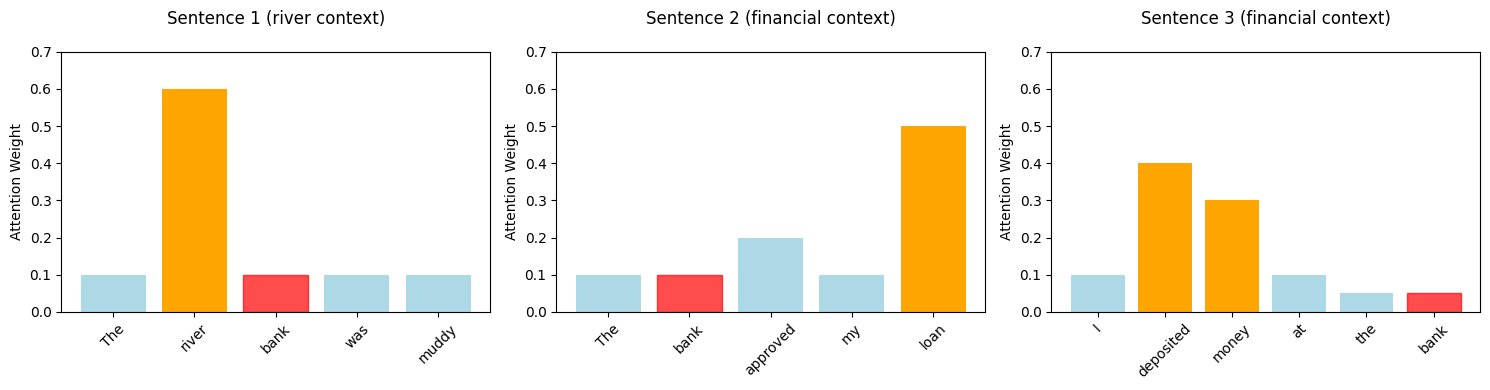

🎯 Key Insight: The word 'bank' attends to different words based on context!
• River context → focuses on 'river' and 'muddy'
• Financial context → focuses on 'loan', 'deposited', 'money'
• Same word, different attention patterns!


In [42]:
from utils import simple_attention_demo

simple_attention_demo()

#### How Attention Updates Embeddings

The attention mechanism determines what information to "add" to each word's embedding, effectively "nudging" its direction in high-dimensional space based on context.

## Word Disambiguation: How Attention Resolves Ambiguity 🔍

Attention solves two types of word ambiguity:
1. **Semantic disambiguation:** Completely different meanings
2. **Contextual refinement:** Same concept, different specifics

Let's see both in action:

### Example 1: Semantic Disambiguation - "Mole" 🔬

**Challenge:** Same word, completely different semantic categories

- American shrew **mole**.
- One **mole** of carbon dioxide.
- Take a biopsy of the **mole**.


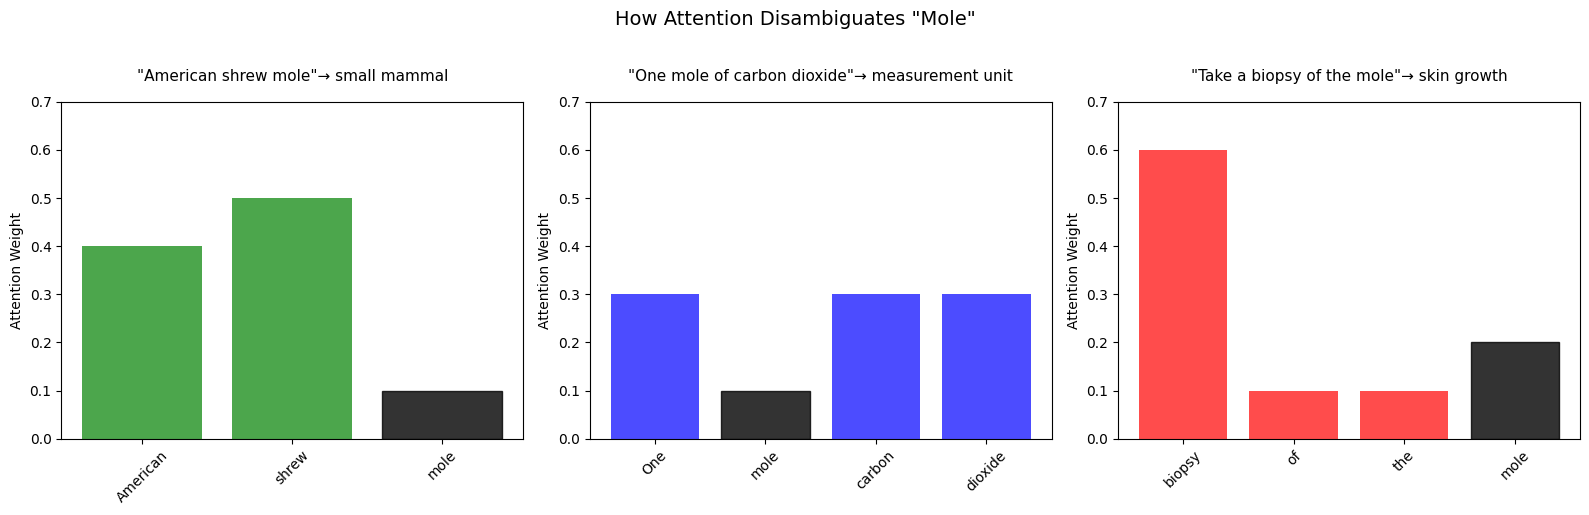

💡 The Magic of Context:
• Same word 'mole' gets different meanings based on what it pays attention to
• Animal context: focuses on 'American' and 'shrew'
• Chemistry context: focuses on 'One', 'carbon', 'dioxide'
• Medical context: focuses on 'biopsy'


In [43]:
from utils import visualize_mole_disambiguation

visualize_mole_disambiguation()

**How attention resolves semantic ambiguity:**
- **Animal context:** "mole" attends to "American", "shrew" → *small mammal*
- **Chemistry context:** "mole" attends to "One", "carbon dioxide" → *measurement unit*  
- **Medical context:** "mole" attends to "biopsy" → *skin growth*

**Result:** Same word gets completely different semantic representations based on attention patterns.

### Example 2: Contextual Refinement - "Tower" 🗼

**Challenge:** Same concept, but context adds specific details

- Look at that tall **tower**
- Look at that tall Effel **tower**
- Look at that miniature Eiffel **tower**

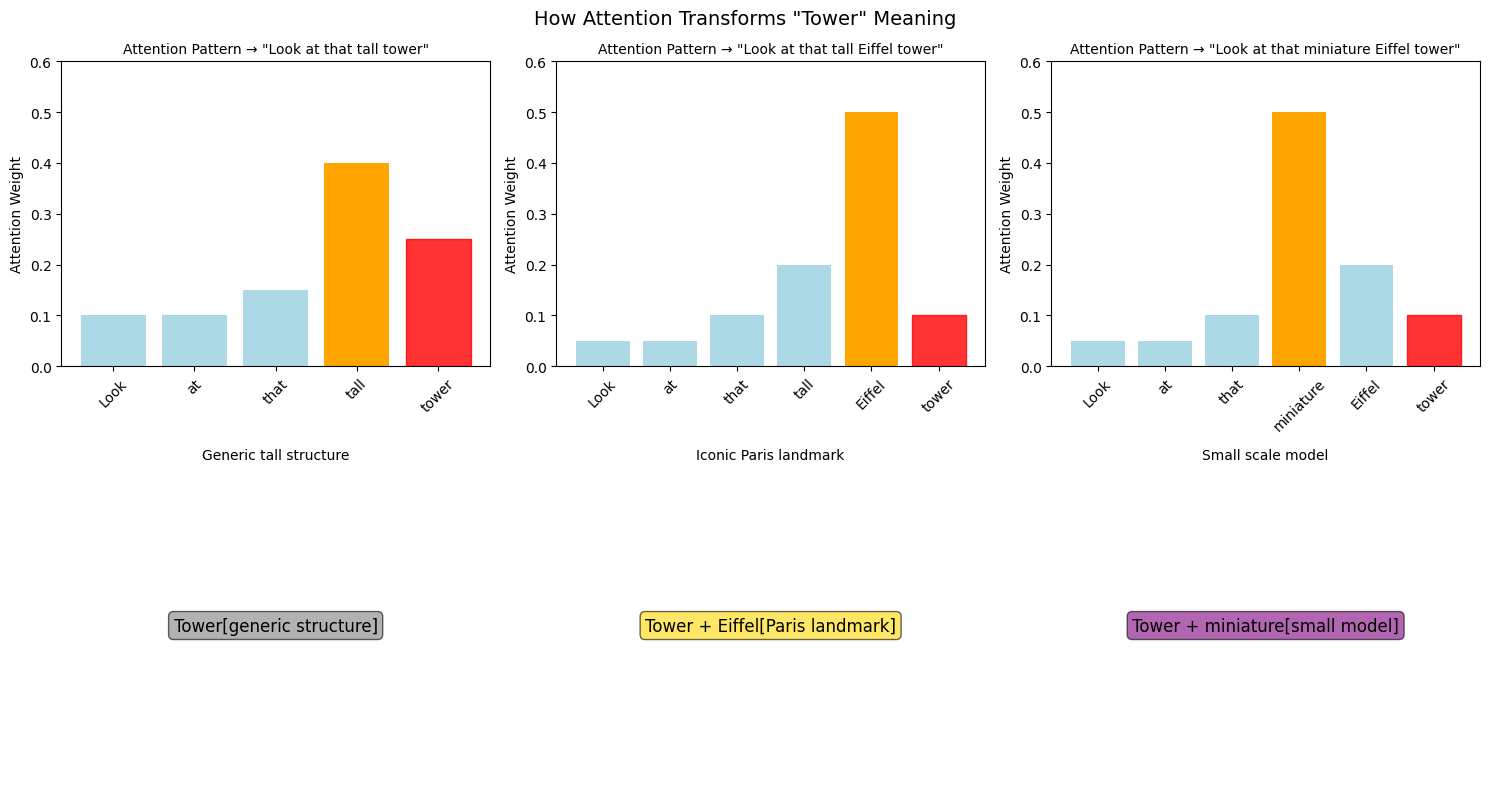

🔄 The Attention Process:
1. 'tower' asks: 'What describes me?'
2. Other words respond with relevance scores
3. High-scoring words update tower's meaning
4. Result: Context-specific representation!


In [44]:
from utils import interactive_tower_attention

interactive_tower_attention()

**How attention refines contextual meaning:**
- **Generic:** "tall tower" → *unspecified tall structure*
- **Specific landmark:** "Eiffel tower" attends to "Eiffel" → *iconic Paris landmark*
- **Scale specification:** "miniature tower" attends to "miniature" → *small model*

**Result:** Base concept stays the same (tower = tall structure) but gets enriched with contextual details.

### The Key Difference

**Semantic disambiguation (mole):** Attention chooses between completely different meanings  
**Contextual refinement (tower):** Attention adds layers of specific information to a base concept

Both demonstrate attention's power to create **dynamic, context-aware representations**!


## Long-Range Dependencies - The Detective Story 🕵️

Let's see how attention helps solve a mystery by connecting clues across long text:


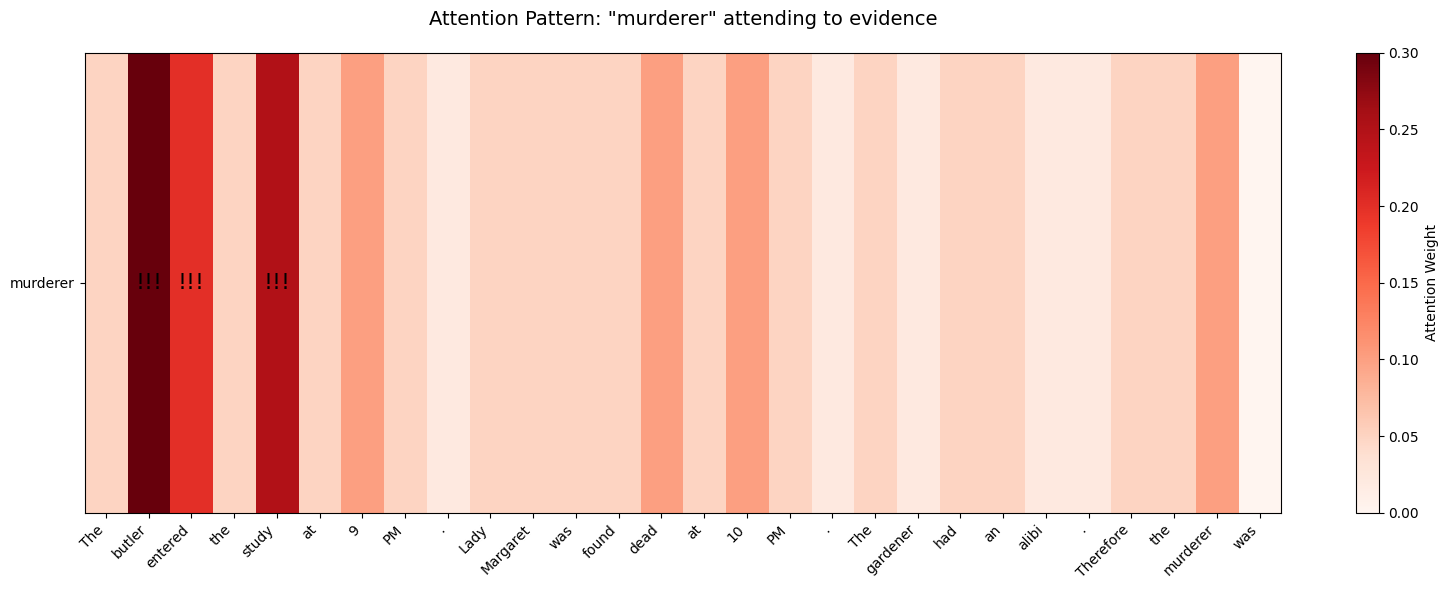

!!! Detective's Attention Pattern:
🟥 High attention (red) → Key evidence: butler, entered, study, dead, 10 PM
🟨 Medium attention → Contextual info: Therefore, the
⬜ Low attention → Less relevant: articles, punctuation
💡 Result: Model can predict 'butler' based on accumulated evidence!


In [45]:
from utils import detective_attention_demo

detective_attention_demo()

#### The Memory Palace Analogy 🏛️

Think of attention like a **memory palace:**
- Each word creates a "room" with information
- When predicting, attention "visits" relevant rooms
- Gathers and combines key information for decisions

**Result:** Long-range reasoning across entire sequences!

## The Attention Pattern: Query-Key-Value Explained 🔑

**The Complete Query-Key-Value System:**

Think of attention as a **smart matching system** where words can share information:

**Another Analogy:** Web search

Each token's embedding vector is transformed into three vectors: **Query (Q)**, **Key (K)**, and **Value (V)**. These vectors are derived by multiplying the input embedding matrix with learned weight matrices for **Q**, **K**, and **V**.

#### 🔍 Query (Q): "The Searcher"
- **What it does:** Each word asks "What information would help me understand my role in this sentence?"
- **Simple example:** _"The red car"_ → "car" asks "Are there any words describing what kind of car I am?"
- **Think of it as:** The specific search terms you type into Google to find exactly what you need

#### 🗝️ Key (K): "The Search Results" 
- **What it does:** Each word advertises "Here's what information I can provide!"
- **Simple example:** "red" says "I'm a color that can describe things!"
- **Think of it as:** The webpage titles and snippets in search results

#### 💎 Value (V): "The Webpage Content"
- **What it does:** Contains the actual information to share
- **Simple example:** "red" holds rich color and visual information
- **Think of it as:** The actual content you see after clicking on a search result

**The Magic Process:**

```
1. Match interests: Query × Key = "How well do we match?"
2. Pick the best: Softmax = "Who gets my attention?" 
3. Share information: Attention × Value = "Here's what I learned!"
```

**Result:** Words get updated with relevant information from other words!

In [46]:
from utils import demonstrate_qkv_process

demonstrate_qkv_process()

🎬 Scene: Processing 'The red car'


Press Enter to continue... 



📋 Step 1: Each word creates Query, Key, Value

'red':
  Query: What nouns do I describe?
  Key: I'm a color adjective
  Value: [color info, visual properties]

'car':
  Query: What words describe me?
  Key: I'm a vehicle noun
  Value: [vehicle info, transportation]



Press Enter to see attention scoring... 



🎯 Step 2: Calculate Attention Scores
car_query × red_key = HIGH SCORE ✅ (adjective-noun match)
red_query × car_key = LOW SCORE ❌ (red doesn't need car info)



Press Enter to see probability conversion... 



📊 Step 3: Convert to Probabilities
car pays: 80% attention to red, 20% to itself
red pays: 10% attention to car, 90% to itself



Press Enter to see the final result... 



🎉 Step 4: Final Result
car_embedding = original_car + 0.8 × red_information
→ car now knows it's red! 🔴🚗

✨ That's the magic of attention! ✨


## Let's See the Math! 🧮

Time to work through actual numbers to see how attention really works:

### Self Attention:

In [47]:
import torch
print("🔢 Mathematical Attention Example: 'red car'")
print("=" * 60)

# Initial embeddings (2D for simplicity)
red_embedding = torch.tensor([0.8, 0.2])  # High color, low vehicle
car_embedding = torch.tensor([0.1, 0.9])  # Low color, high vehicle

print(f"\n📊 Initial Embeddings:")
print(f"red = {red_embedding.tolist()} (high color dimension)")
print(f"car = {car_embedding.tolist()} (high vehicle dimension)")

🔢 Mathematical Attention Example: 'red car'

📊 Initial Embeddings:
red = [0.800000011920929, 0.20000000298023224] (high color dimension)
car = [0.10000000149011612, 0.8999999761581421] (high vehicle dimension)


In [49]:
# Weight matrices (2x2 for simplicity)
W_q = torch.tensor([[0.5, 0.3], [0.2, 0.7]])
W_k = torch.tensor([[0.4, 0.6], [0.8, 0.1]]) 
W_v = torch.tensor([[1.0, 0.2], [0.3, 0.8]])

# Generate Q, K, V
red_query = red_embedding @ W_q
red_key = red_embedding @ W_k
red_value = red_embedding @ W_v

car_query = car_embedding @ W_q  
car_key = car_embedding @ W_k
car_value = car_embedding @ W_v

print(f"\n🎯 Generated Vectors:")
print(f"red_query = {red_query.round(decimals=2).tolist()}")
print(f"red_key = {red_key.round(decimals=2).tolist()}")
print(f"red_value = {red_value.round(decimals=2).tolist()}")
print("--------------------------------------------------------")
print(f"car_query = {car_query.round(decimals=2).tolist()}")
print(f"car_key = {car_key.round(decimals=2).tolist()}")
print(f"car_value = {car_value.round(decimals=2).tolist()}")


🎯 Generated Vectors:
red_query = [0.4399999976158142, 0.3799999952316284]
red_key = [0.47999998927116394, 0.5]
red_value = [0.8600000143051147, 0.3199999928474426]
--------------------------------------------------------
car_query = [0.23000000417232513, 0.6600000262260437]
car_key = [0.7599999904632568, 0.15000000596046448]
car_value = [0.3700000047683716, 0.7400000095367432]


In [50]:
 # Calculate attention scores
car_to_red_score = torch.dot(car_query, red_key)
car_to_car_score = torch.dot(car_query, car_key)

print(f"\n🔍 Attention Scores (Raw Dot Products):")
print(f"car attending to red: {car_to_red_score:.3f}")
print(f"car attending to itself: {car_to_car_score:.3f}")
print(f"Raw scores vector: [{car_to_red_score:.3f}, {car_to_car_score:.3f}]")


🔍 Attention Scores (Raw Dot Products):
car attending to red: 0.440
car attending to itself: 0.274
Raw scores vector: [0.440, 0.274]


In [52]:
# Apply softmax - show the step-by-step process
scores = torch.tensor([car_to_red_score, car_to_car_score])

print(f"\n⚖️ Softmax Transformation:")
print(f"Step 1 - Raw scores: {scores.round(decimals=3).tolist()}")

# The exponential function increases the gap between scores (amplifying stronger preferences)
exp_scores = torch.exp(scores)
print(f"Step 2 - Apply exp(): {exp_scores.round(decimals=3).tolist()}")

# take sum - used to normalize the values into a probability distribution
sum_exp = torch.sum(exp_scores)
print(f"Step 3 - Sum of exp(): {sum_exp:.3f}")

# Final probabilities
attention_weights = exp_scores / sum_exp
print(f"Step 4 - Normalize: {attention_weights.round(decimals=3).tolist()}")

# Verify it's a probability distribution
print(f"✅ Sum check: {attention_weights.sum():.3f} (should be 1.0)")
print(f"→ car pays {attention_weights[0]:.1%} attention to red!")
print(f"→ car pays {attention_weights[1]:.1%} attention to itself!")


⚖️ Softmax Transformation:
Step 1 - Raw scores: [0.4399999976158142, 0.27399998903274536]
Step 2 - Apply exp(): [1.5529999732971191, 1.315000057220459]
Step 3 - Sum of exp(): 2.868
Step 4 - Normalize: [0.5419999957084656, 0.4580000042915344]
✅ Sum check: 1.000 (should be 1.0)
→ car pays 54.2% attention to red!
→ car pays 45.8% attention to itself!


The softmax function transforms raw scores (called logits) into probabilities, so that:
- All outputs are positive
- All outputs sum to 1
- Larger scores get proportionally higher probability

In [53]:
# Final weighted combination
new_car = attention_weights[0] * red_value + attention_weights[1] * car_value # every token plus itself

print(f"\n🎉 Final Result:")
print(f"Original car = {car_embedding.tolist()}")
print(f"Updated car = {new_car.round(decimals=2).tolist()}")
print(f"→ car now has significant color information! 🎨")

print(f"\n🔄 Summary: Scores → Weights")
print(f"Raw scores: {scores.round(decimals=3).tolist()} (can be negative/any range)")
print(f"Final weights: {attention_weights.round(decimals=3).tolist()} (always positive, sum to 1)")


🎉 Final Result:
Original car = [0.10000000149011612, 0.8999999761581421]
Updated car = [0.6399999856948853, 0.5099999904632568]
→ car now has significant color information! 🎨

🔄 Summary: Scores → Weights
Raw scores: [0.4399999976158142, 0.27399998903274536] (can be negative/any range)
Final weights: [0.5419999957084656, 0.4580000042915344] (always positive, sum to 1)


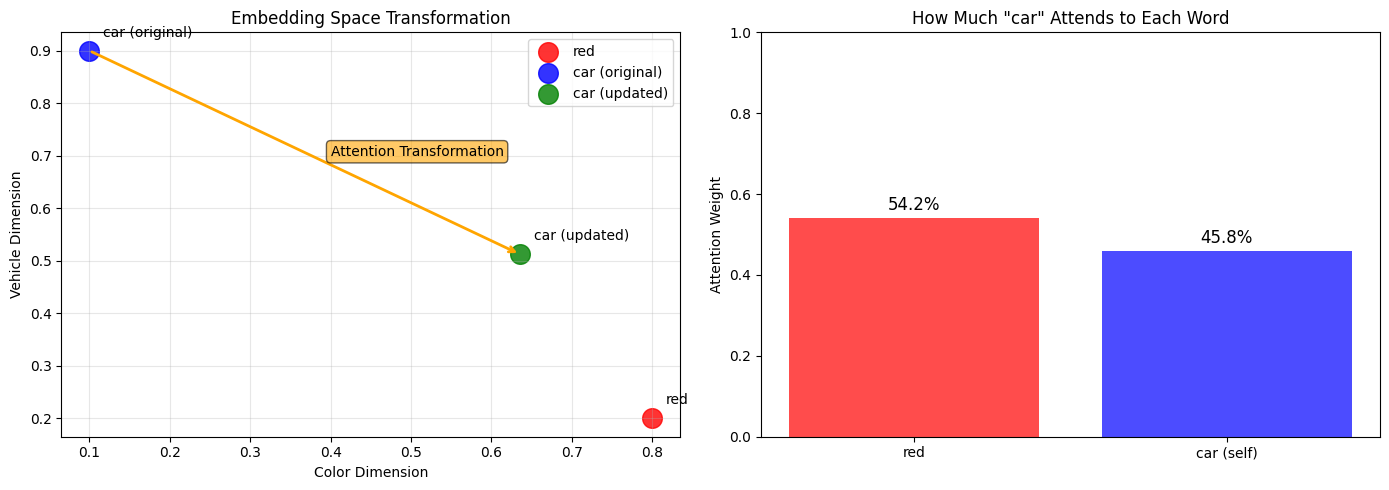

🔍 Key Insight:
• car's color dimension increased from 0.1 to 0.6
• This happened because car paid 54.2% attention to red!
• Attention literally moves embeddings in semantic space! 🚀


In [54]:
from utils import visualize_embedding_transformation

visualize_embedding_transformation(red_embedding, car_embedding, new_car, attention_weights)

### Causal Attension (Masked self-attention)
**Definition:** A form of self-attention that prevents tokens from attending to future tokens.

**Used in:** Decoder-only models like GPT, LLaMA, etc.

**Purpose:** Enforces left-to-right generation, where each token can only "see" past or current tokens

In [ ]:
from utils import mathematical_attention_example_full_masked

the_embedding, red_embedding, car_embedding, new_the, new_red, new_car = mathematical_attention_example_full_masked()

## Visualizing Attention with BertViz

Let's explore attention patterns in a real GPT-2 model using BertViz:

### Interactive Attention Exploration

Run the cell below to explore attention patterns interactively. Click on different words to see what they pay attention to!

In [56]:
from bertviz.transformers_neuron_view import GPT2Model, GPT2Tokenizer
from bertviz.neuron_view import show

model_type = 'gpt2'
model_version = 'gpt2'
model = GPT2Model.from_pretrained(model_version)
tokenizer = GPT2Tokenizer.from_pretrained(model_version)
text = "a fluffy blue creature roamed the verdant forest"
show(model, model_type, tokenizer, text, display_mode='light', layer=4, head=3)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

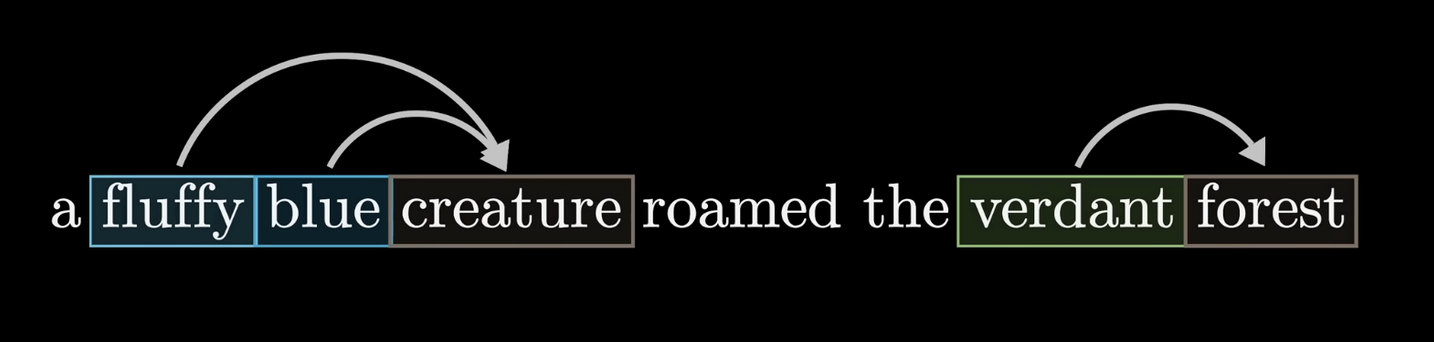

### Understanding BertViz Components

**🕵️‍♀️ How to "Read" Attention Visualizations:**

#### Visual Elements
- **Blue bars:** Low importance | **Orange bars:** High importance
- **Thick lines:** Strong connections | **Thin lines:** Weak connections  
- **Mathematical steps:** q×k → dot product → softmax (converts to probabilities)

#### 🎯 Interactive Tips
**Try clicking on different words:**
- **"creature"** → attends to descriptive adjectives
- **"fluffy"** → focuses on the noun it describes  
- **"roamed"** → may connect subject and location

#### Layers vs Heads 🧠
- **Layers (1-12):** Simple patterns → Complex reasoning → Abstract concepts
- **Heads (parallel):** Different "experts" learning different relationship types
1. Layers:

    - A Transformer has multiple layers (also called blocks).
    - Each layer is a stacked unit that:
        - Runs multi-head self-attention
        - Applies a feedforward network
        - Includes residuals + normalization
    - Think of layers like steps in a neural reasoning ladder — each layer builds on the last.


2. Heads (Inside Each Layer):
    - Inside each layer’s self-attention module are multiple attention heads.
    - All heads operate in parallel.
    - Each head:
        - Learns different attention patterns
        - Has its own Q, K, V projection matrices
     
```python
Transformer Layer
├── Head 1 (focuses on subject-verb links)
├── Head 2 (tracks coreference)
├── Head 3 (captures punctuation context)
├── Head 4 ...
...
└── Head N


```

**What to look for:** Nouns attending to adjectives, verbs to subjects, pronouns to antecedents

## How Attention Enables Text Generation 🔮

**The key question:** How does attention help predict the next word?

### Mystery Novel Example
**Context:** *"The butler's alibi was suspicious... Therefore, the murderer was..."*

**Attention's detective work:**
1. **Gathers clues** → Focus on "butler", "suspicious", evidence
2. **Builds rich context** → Combines all relevant information  
3. **Makes informed prediction** → "butler" (high probability)

### Why This Matters

**Traditional models:** Limited context, no long-range reasoning  
**Attention models:** Global context, connect clues across entire text

**At each generation step:**
- Attention scans ALL previous words
- Builds context-aware representation
- Enables coherent, logical continuations

### Multi-Head Attention: Parallel Experts 🧠

Different heads focus on different aspects:
- **Head 1:** Character relationships ("butler" ↔ "murderer")
- **Head 2:** Evidence connections ("clean shoes" ↔ "alibi")  
- **Head 3:** Logical flow ("suspicious" ↔ "therefore")

**Result:** Rich understanding enabling sophisticated text generation.

## 📚 Attention Quick Reference

**Core Components:**
- **Query (Q):** "What do I need?" - Each word's search request
- **Key (K):** "What do I offer?" - Each word's advertisement  
- **Value (V):** "Here's the content!" - Actual information to share

**The Process:** Match interests → Pick the best → Share information

## Section Summary

**Key insights:**

1. **Dynamic attention:** Words dynamically weight importance of all other words
2. **Context-aware representations:** Rich, context-dependent meanings vs. static embeddings
3. **Multiple perspectives:** Different heads learn different relationship types
4. **Long-range reasoning:** Connect information across entire sequences
5. **Generation capability:** Rich context enables informed next-word predictions

**The power of attention:** Transforms static word meanings into dynamic, context-aware representations that capture complex relationships in text.

---

## 🔗 Connection to GPT Architecture

**You now understand the "brain" of transformers!** Attention is the core innovation, but to build a complete LLM, we need:

✅ **Attention mechanisms** ← You just mastered this!  
🔄 **Layer normalization** ← Stabilizes deep network training  
🔄 **Feed-forward networks** ← Adds processing capacity  
🔄 **Residual connections** ← Enables gradient flow  
🔄 **Complete GPT assembly** ← Puts it all together

**🔜 Next up:** Building the complete GPT architecture by combining attention with other essential components for production-ready language models.

---

# 3. GPT Architecture Overview

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/04.webp?123" width="500px">

The GPT model consists of several key components working together.

### Component Structure

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/03.webp" width="500px">

Let's explore each component that makes up a Transformer block.

## Layer Normalization

**Purpose:** Stabilizes and accelerates training of deep neural networks

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

**How it works:**
- Rescales values to have constant mean and variance for each layer
- Prevents vanishing and exploding gradient problems
- Applied before attention and feed-forward components

- layer normalization is a technique used to stabilize and accelerate the training of deep neural networks
- for each layer, it rescaled the calues to have a constant mean and variance
- this helps to prevent the vanishing and exploding gradient problems, which can occur when training deep neural networks

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/05.webp" width="400px">

## GELU Activation Function

**Purpose:** Provides non-linear activation that keeps learning stable

**Characteristics:**
- Smoother than ReLU
- Allows some negative values through
- Used in the feed-forward network

- type of "switch" applied after the linear layer
- keeps learning stable

## Feed-Forward Network

**Purpose:** Processes attention output and adds model flexibility

**Structure:**
- Simple neural network applied to each position
- Expands dimensionality, applies activation, then contracts
- Gives the model capacity to learn complex relationships beyond attention

- simple neural network that processes the output of the attention mechanism
- gives model more flexibility to learn complex relationships in the data

## Shortcut Connections

**Purpose:** Enable easier training of deep networks

**Benefits:**
- Allow gradients to flow directly through the network
- Help prevent vanishing gradient problems
- Enable training of much deeper models
- Connect input directly to output, skipping intermediate layers

- these connections allow the model to skip over some layers and directly connect the input to the output
- this makes it easier for the model to learn and helps to prevent the vanishing gradient problem

## Transformer Block

**Complete integration:** Combines all components into a single processing unit

**Components working together:**
- Multi-head attention mechanism (context and relationships)
- Feed-forward network (additional processing capacity)  
- Layer normalization (training stability)
- Shortcut connections (gradient flow)

**Stacking:** GPT models use many of these blocks in sequence for sophisticated text understanding.

- A multi-head attention mechanism (to understand context and relationships between words).
- The feed-forward network (for further processing).
- Layer normalization (applied before attention and feed-forward layers).
- Shortcut connections (around the attention and feed-forward components). The GPT model stacks many of these blocks on top of each other.

### Transformer Block Visualization

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/15.webp" width="500px">

This diagram shows how all components integrate within a single Transformer block.

## Generating Text with GPT

**Process:** GPT generates text one token at a time using greedy decoding

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/16.webp" width="400px">

### Greedy Decoding Strategy

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch04_compressed/17.webp" width="600px">

**How it works:**
- At each step, select the token with highest probability
- Fast and deterministic generation method
- Token with highest logit = highest probability (no softmax needed)

**Trade-off:** Simple but can be repetitive; more advanced strategies exist for better diversity.

### Demo: Running the GPT Model

You can test the complete implementation by running:

```bash
uv run gpt.py
```

This script demonstrates the full GPT model in action, generating text from a given prompt.

## Section Summary

**What we've accomplished:**
- Built a complete GPT architecture from individual components
- Implemented layer normalization for training stability
- Added GELU activation functions for non-linear processing  
- Created feed-forward networks for additional model capacity
- Integrated shortcut connections for deep network training
- Assembled everything into functional Transformer blocks
- Implemented greedy text generation

**🗺️ Where we are:** We have a fully functional GPT model that can generate text, but it produces random outputs because it hasn't been trained yet.

**🔜 What's next:** Training our model on real data to learn language patterns, implementing loss functions, and monitoring training progress to transform random outputs into coherent text.

---

# 4. Training a GPT Model

**Training overview:** Transform our GPT model from random initialization to coherent text generation through supervised learning.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model--0.webp" width="400px">

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/mental-model--0.webp" width=400px>

## Understanding Loss Metrics

### Training Loss
**Purpose:** Measures model performance on training data  
**Goal:** Should decrease as training progresses  
**Calculation:** Compare model predictions to actual target values

### Training loss

- measure of how well the model is performing on the training data
- as training , we want the training loss to decrease
- the training loss is calculated by comparing the model's predictions to the actual target values in the training data

### Validation Loss  
**Purpose:** Measures how well the model generalizes to unseen data  
**Importance:** Detects overfitting when training loss decreases but validation loss increases  
**Calculation:** Same as training loss, but on separate validation dataset

- how well the model generalizes to unseen data
- we calculate the validation loss on a separate validation dataset that the model has not seen during training
- the validation loss is calculated in the same way as the training loss, but using the validation dataset

## Training Setup and Execution

Let's set up our GPT model and begin training on *The Verdict* dataset.

In [57]:
import torch
from llms_from_scratch.ch04 import GPTModel
# If the `previous_chapters.py` file is not available locally,
# you can import it from the `llms-from-scratch` PyPI package.
# For details, see: https://github.com/rasbt/LLMs-from-scratch/tree/main/pkg
# E.g.,
# from llms_from_scratch.ch04 import GPTModel

GPT_CONFIG_124M = {
    "vocab_size": 50257,   # Vocabulary size
    "context_length": 256, # Shortened context length (orig: 1024)
    "emb_dim": 768,        # Embedding dimension
    "n_heads": 12,         # Number of attention heads
    "n_layers": 12,        # Number of layers
    "drop_rate": 0.1,      # Dropout rate
    "qkv_bias": False      # Query-key-value bias
}

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.eval();  # Disable dropout during inference

In [58]:
import os
import urllib.request
from llms_from_scratch.ch04 import generate_text_simple

def text_to_token_ids(text, tokenizer):
    encoded = tokenizer.encode(text, allowed_special={'<|endoftext|>'})
    encoded_tensor = torch.tensor(encoded).unsqueeze(0) # add batch dimension
    return encoded_tensor

def token_ids_to_text(token_ids, tokenizer):
    flat = token_ids.squeeze(0) # remove batch dimension
    return tokenizer.decode(flat.tolist())

start_context = "Every effort moves you"
tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids(start_context, tokenizer),
    max_new_tokens=10,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

file_path = "the-verdict.txt"
url = "https://raw.githubusercontent.com/rasbt/LLMs-from-scratch/main/ch02/01_main-chapter-code/the-verdict.txt"

if not os.path.exists(file_path):
    with urllib.request.urlopen(url) as response:
        text_data = response.read().decode('utf-8')
    with open(file_path, "w", encoding="utf-8") as file:
        file.write(text_data)
else:
    with open(file_path, "r", encoding="utf-8") as file:
        text_data = file.read()

Output text:
 Every effort moves you rentingetic wasnم refres RexMeCHicular stren


### Initial Model Performance

Let's test our untrained model and examine the dataset:

In [59]:
# First 100 characters
print(text_data[:99])

I HAD always thought Jack Gisburn rather a cheap genius--though a good fellow enough--so it was no 


In [60]:
# Last 100 characters
print(text_data[-99:])

it for me! The Strouds stand alone, and happen once--but there's no exterminating our kind of art."


In [61]:
total_characters = len(text_data)
total_tokens = len(tokenizer.encode(text_data))

print("Characters:", total_characters)
print("Tokens:", total_tokens)

Characters: 20479
Tokens: 5145


In [62]:
# Alternatively:
from llms_from_scratch.ch02 import create_dataloader_v1

# Train/validation ratio
train_ratio = 0.90
split_idx = int(train_ratio * len(text_data))
train_data = text_data[:split_idx]
val_data = text_data[split_idx:]


torch.manual_seed(123)

train_loader = create_dataloader_v1(
    train_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=True,
    shuffle=True,
    num_workers=0
)

val_loader = create_dataloader_v1(
    val_data,
    batch_size=2,
    max_length=GPT_CONFIG_124M["context_length"],
    stride=GPT_CONFIG_124M["context_length"],
    drop_last=False,
    shuffle=False,
    num_workers=0
)

In [63]:
print("Train loader:")
for x, y in train_loader:
    print(x.shape, y.shape)

print("\nValidation loader:")
for x, y in val_loader:
    print(x.shape, y.shape)

Train loader:
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])
torch.Size([2, 256]) torch.Size([2, 256])

Validation loader:
torch.Size([2, 256]) torch.Size([2, 256])


### Loss Calculation Functions

Before training, let's implement functions to calculate training and validation losses:

In [64]:
def calc_loss_batch(input_batch, target_batch, model, device):
    input_batch, target_batch = input_batch.to(device), target_batch.to(device)
    logits = model(input_batch)
    loss = torch.nn.functional.cross_entropy(logits.flatten(0, 1), target_batch.flatten())
    return loss


def calc_loss_loader(data_loader, model, device, num_batches=None):
    total_loss = 0.
    if len(data_loader) == 0:
        return float("nan")
    elif num_batches is None:
        num_batches = len(data_loader)
    else:
        # Reduce the number of batches to match the total number of batches in the data loader
        # if num_batches exceeds the number of batches in the data loader
        num_batches = min(num_batches, len(data_loader))
    for i, (input_batch, target_batch) in enumerate(data_loader):
        if i < num_batches:
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            total_loss += loss.item()
        else:
            break
    return total_loss / num_batches

In [65]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Note:
# Uncommenting the following lines will allow the code to run on Apple Silicon chips, if applicable,
# which is approximately 2x faster than on an Apple CPU (as measured on an M3 MacBook Air).
# However, the resulting loss values may be slightly different.

if torch.cuda.is_available():
   device = torch.device("cuda")
elif torch.backends.mps.is_available():
   device = torch.device("mps")
else:
   device = torch.device("cpu")

print(f"Using {device} device.")


model.to(device) # no assignment model = model.to(device) necessary for nn.Module classes


torch.manual_seed(123) # For reproducibility due to the shuffling in the data loader

with torch.no_grad(): # Disable gradient tracking for efficiency because we are not training, yet
    train_loss = calc_loss_loader(train_loader, model, device)
    val_loss = calc_loss_loader(val_loader, model, device)

print("Training loss:", train_loss)
print("Validation loss:", val_loss)

Using mps device.
Training loss: 10.987583054436577
Validation loss: 10.98110580444336


### Training Loop Implementation

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/train-steps.webp" width="400px">

The training loop follows these steps for each batch:
1. **Forward pass:** Calculate model predictions
2. **Loss calculation:** Compare predictions to targets  
3. **Backward pass:** Compute gradients
4. **Parameter update:** Adjust model weights

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/train-steps.webp" width=400px>

In [66]:
def train_model_simple(model, train_loader, val_loader, optimizer, device, num_epochs,
                       eval_freq, eval_iter, start_context, tokenizer):
    # Initialize lists to track losses and tokens seen
    train_losses, val_losses, track_tokens_seen = [], [], []
    tokens_seen, global_step = 0, -1

    # Main training loop
    for epoch in range(num_epochs):
        model.train()  # Set model to training mode
        
        for input_batch, target_batch in train_loader:
            optimizer.zero_grad() # Reset loss gradients from previous batch iteration
            loss = calc_loss_batch(input_batch, target_batch, model, device)
            loss.backward() # Calculate loss gradients
            optimizer.step() # Update model weights using loss gradients
            tokens_seen += input_batch.numel()
            global_step += 1

            # Optional evaluation step
            if global_step % eval_freq == 0:
                train_loss, val_loss = evaluate_model(
                    model, train_loader, val_loader, device, eval_iter)
                train_losses.append(train_loss)
                val_losses.append(val_loss)
                track_tokens_seen.append(tokens_seen)
                print(f"Ep {epoch+1} (Step {global_step:06d}): "
                      f"Train loss {train_loss:.3f}, Val loss {val_loss:.3f}")

        # Print a sample text after each epoch
        generate_and_print_sample(
            model, tokenizer, device, start_context
        )

    return train_losses, val_losses, track_tokens_seen


def evaluate_model(model, train_loader, val_loader, device, eval_iter):
    model.eval()
    with torch.no_grad():
        train_loss = calc_loss_loader(train_loader, model, device, num_batches=eval_iter)
        val_loss = calc_loss_loader(val_loader, model, device, num_batches=eval_iter)
    model.train()
    return train_loss, val_loss


def generate_and_print_sample(model, tokenizer, device, start_context):
    model.eval()
    context_size = model.pos_emb.weight.shape[0]
    encoded = text_to_token_ids(start_context, tokenizer).to(device)
    with torch.no_grad():
        token_ids = generate_text_simple(
            model=model, idx=encoded,
            max_new_tokens=50, context_size=context_size
        )
    decoded_text = token_ids_to_text(token_ids, tokenizer)
    print(decoded_text.replace("\n", " "))  # Compact print format
    model.train()

In [67]:
import time
import torch
start_time = time.time()

torch.manual_seed(123)
model = GPTModel(GPT_CONFIG_124M)
model.to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=0.0004, weight_decay=0.1)

num_epochs = 10
train_losses, val_losses, tokens_seen = train_model_simple(
    model, train_loader, val_loader, optimizer, device,
    num_epochs=num_epochs, eval_freq=5, eval_iter=5,
    start_context="Every effort moves you", tokenizer=tokenizer
)

# Note:
# Uncomment the following code to show the execution time
end_time = time.time()
execution_time_minutes = (end_time - start_time) / 60
print(f"Training completed in {execution_time_minutes:.2f} minutes.")

Ep 1 (Step 000000): Train loss 9.817, Val loss 9.924
Ep 1 (Step 000005): Train loss 8.066, Val loss 8.332
Every effort moves you,,,,,,,,,,,,.                                     
Ep 2 (Step 000010): Train loss 6.619, Val loss 7.042
Ep 2 (Step 000015): Train loss 6.046, Val loss 6.596
Every effort moves you, and,, and, and,,,,, and, and,,,,,,,,,,, and,, the,, the, and,, and,,, the, and,,,,,,
Ep 3 (Step 000020): Train loss 5.524, Val loss 6.508
Ep 3 (Step 000025): Train loss 5.369, Val loss 6.378
Every effort moves you, and to the of the of the picture. Gis.                                     
Ep 4 (Step 000030): Train loss 4.830, Val loss 6.263
Ep 4 (Step 000035): Train loss 4.586, Val loss 6.285
Every effort moves you of the "I the picture.                    "I"I the picture"I had the picture"I the picture and I had been the picture of
Ep 5 (Step 000040): Train loss 3.879, Val loss 6.130
Every effort moves you know he had been his pictures, and I felt it's by his last word.          

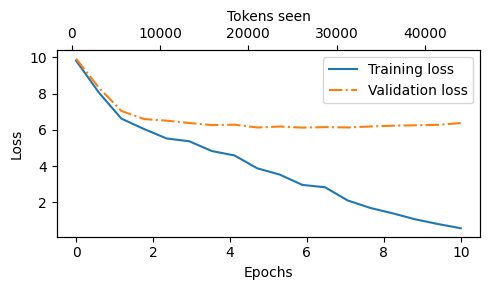

In [68]:
import matplotlib.pyplot as plt
from matplotlib.ticker import MaxNLocator


def plot_losses(epochs_seen, tokens_seen, train_losses, val_losses):
    fig, ax1 = plt.subplots(figsize=(5, 3))

    # Plot training and validation loss against epochs
    ax1.plot(epochs_seen, train_losses, label="Training loss")
    ax1.plot(epochs_seen, val_losses, linestyle="-.", label="Validation loss")
    ax1.set_xlabel("Epochs")
    ax1.set_ylabel("Loss")
    ax1.legend(loc="upper right")
    ax1.xaxis.set_major_locator(MaxNLocator(integer=True))  # only show integer labels on x-axis

    # Create a second x-axis for tokens seen
    ax2 = ax1.twiny()  # Create a second x-axis that shares the same y-axis
    ax2.plot(tokens_seen, train_losses, alpha=0)  # Invisible plot for aligning ticks
    ax2.set_xlabel("Tokens seen")

    fig.tight_layout()  # Adjust layout to make room
    plt.savefig("loss-plot.pdf")
    plt.show()

epochs_tensor = torch.linspace(0, num_epochs, len(train_losses))
plot_losses(epochs_tensor, tokens_seen, train_losses, val_losses)

### Training Results Analysis

**Observations from training:**

1. **Progressive improvement:** Model starts generating incomprehensible tokens and gradually produces grammatically correct sentences

2. **Overfitting detected:** Training loss decreases while validation loss plateaus/increases
   - Training loss: 10.99 → 0.57
   - Validation loss: 10.98 → 6.37

3. **Memorization behavior:** Towards the end, the model memorizes training passages verbatim due to:
   - Very small training dataset
   - Multiple iterations over the same data

4. **Educational purpose:** This demonstrates core concepts; production models require:
   - Much larger datasets
   - Longer training periods
   - Specialized hardware

## Section Summary

**What we've accomplished:**
- Implemented complete training pipeline with loss calculation
- Successfully trained a GPT model from random initialization to coherent text generation
- Monitored both training and validation losses to detect overfitting
- Observed the learning progression from random tokens to grammatical sentences
- Understood the challenges of small dataset training

**🗺️ Where we are:** We have a working, trained LLM that can generate coherent text, but it's limited by deterministic output and potential memorization.

**🔜 What's next:** Implementing advanced decoding strategies (temperature scaling and top-k sampling) to control randomness, improve diversity, and reduce memorization in text generation.

# 5. Advanced Text Generation Strategies

**Beyond greedy decoding:** We can improve text generation quality and diversity by implementing advanced decoding strategies that control randomness and token selection.

## Current Limitation: Deterministic Output

Let's first examine our current text generation behavior:

In [69]:
model.to("cpu")
model.eval()

tokenizer = tiktoken.get_encoding("gpt2")

token_ids = generate_text_simple(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=25,
    context_size=GPT_CONFIG_124M["context_length"]
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and by me!"




### The Problem

**Issue:** The `generate_text_simple` function always produces identical outputs because it uses greedy decoding (always selecting the highest probability token).

**Solution:** We need decoding strategies that introduce controlled randomness for more diverse and interesting text generation.

## Temperature Scaling

**Concept:** Temperature scaling controls the "confidence" of probability distributions by dividing logits by a temperature value.

### How Temperature Works

Let's explore with a simplified vocabulary example:

In [70]:
vocab = { 
    "closer": 0,
    "every": 1, 
    "effort": 2, 
    "forward": 3,
    "inches": 4,
    "moves": 5, 
    "pizza": 6,
    "toward": 7,
    "you": 8,
} 

inverse_vocab = {v: k for k, v in vocab.items()}

# Example logits for next token after "every effort moves you"
next_token_logits = torch.tensor(
    [4.51, 0.89, -1.90, 6.75, 1.63, -1.62, -1.89, 6.28, 1.79]
)

probas = torch.softmax(next_token_logits, dim=0)
next_token_id = torch.argmax(probas).item()

print("Most likely next token:", inverse_vocab[next_token_id])

Most likely next token: forward


### Sampling Instead of Argmax

Rather than always picking the highest probability token, we can sample from the probability distribution:

In [71]:
torch.manual_seed(123)
next_token_id = torch.multinomial(probas, num_samples=1).item()
print("Sampled next token:", inverse_vocab[next_token_id])

# Let's see the distribution when sampling 1000 times
def print_sampled_tokens(probas):
    torch.manual_seed(123)
    sample = [torch.multinomial(probas, num_samples=1).item() for i in range(1_000)]
    sampled_ids = torch.bincount(torch.tensor(sample), minlength=len(probas))
    for i, freq in enumerate(sampled_ids):
        print(f"{freq} x {inverse_vocab[i]}")

print("\nSampling distribution (1000 samples):")
print_sampled_tokens(probas)

Sampled next token: forward

Sampling distribution (1000 samples):
73 x closer
0 x every
0 x effort
582 x forward
2 x inches
0 x moves
0 x pizza
343 x toward
0 x you


### Implementing Temperature Scaling

**Temperature effects:**
- **Temperature > 1:** More uniform distribution (more random)
- **Temperature < 1:** Sharper distribution (more confident)
- **Temperature = 1:** Original distribution

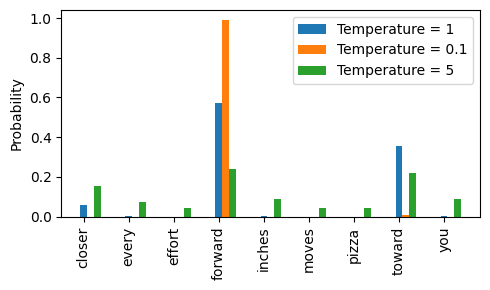

In [72]:
def softmax_with_temperature(logits, temperature):
    scaled_logits = logits / temperature
    return torch.softmax(scaled_logits, dim=0)

# Test different temperature values
temperatures = [1, 0.1, 5]  # Original, higher confidence, lower confidence

# Calculate scaled probabilities
scaled_probas = [softmax_with_temperature(next_token_logits, T) for T in temperatures]

# Visualize the effect
import matplotlib.pyplot as plt

x = torch.arange(len(vocab))
bar_width = 0.15

fig, ax = plt.subplots(figsize=(5, 3))
for i, T in enumerate(temperatures):
    rects = ax.bar(x + i * bar_width, scaled_probas[i], bar_width, label=f'Temperature = {T}')

ax.set_ylabel('Probability')
ax.set_xticks(x)
ax.set_xticklabels(vocab.keys(), rotation=90)
ax.legend()

plt.tight_layout()
plt.show()

#### Temperature 0.1 (High Confidence)

Low temperature makes the model more confident, almost deterministic:

In [73]:
print("Temperature 0.1 sampling (1000 times):")
print_sampled_tokens(scaled_probas[1])

Temperature 0.1 sampling (1000 times):
0 x closer
0 x every
0 x effort
985 x forward
0 x inches
0 x moves
0 x pizza
15 x toward
0 x you


#### Temperature 5 (High Randomness)

High temperature creates more uniform distribution, allowing less likely tokens:

In [74]:
print("Temperature 5 sampling (1000 times):")
print_sampled_tokens(scaled_probas[2])

Temperature 5 sampling (1000 times):
165 x closer
75 x every
42 x effort
239 x forward
71 x inches
46 x moves
32 x pizza
227 x toward
103 x you


**Problem with high temperature:** Can produce nonsensical outputs like "every effort moves you pizza" (3.2% probability).

## Top-k Sampling

**Solution:** Restrict sampling to only the k most likely tokens to maintain diversity while avoiding nonsensical outputs.

<img src="https://sebastianraschka.com/images/LLMs-from-scratch-images/ch05_compressed/topk.webp" width="500px">

### Implementing Top-k Sampling

In [75]:
# Select top-k tokens
top_k = 3
top_logits, top_pos = torch.topk(next_token_logits, top_k)

print("Top logits:", top_logits)
print("Top positions:", top_pos)
print("Corresponding tokens:", [inverse_vocab[pos.item()] for pos in top_pos])

Top logits: tensor([6.7500, 6.2800, 4.5100])
Top positions: tensor([3, 7, 0])
Corresponding tokens: ['forward', 'toward', 'closer']


In [76]:
# Create new logits with only top-k values, others set to -infinity
new_logits = torch.where(
    condition=next_token_logits < top_logits[-1],  # Below the k-th highest
    input=torch.tensor(float("-inf")),             # Set to -infinity
    other=next_token_logits                        # Keep original value
)

print("Modified logits:", new_logits)

# Convert to probabilities
topk_probas = torch.softmax(new_logits, dim=0)
print("Top-k probabilities:", topk_probas)

Modified logits: tensor([4.5100,   -inf,   -inf, 6.7500,   -inf,   -inf,   -inf, 6.2800,   -inf])
Top-k probabilities: tensor([0.0615, 0.0000, 0.0000, 0.5775, 0.0000, 0.0000, 0.0000, 0.3610, 0.0000])


## Enhanced Text Generation Function

Now let's create an improved generation function that combines temperature scaling and top-k sampling:

In [77]:
def generate(model, idx, max_new_tokens, context_size, temperature=0.0, top_k=None, eos_id=None):
    """
    Enhanced text generation with temperature scaling and top-k sampling.
    
    Args:
        model: The GPT model
        idx: Input token IDs (batch_size, sequence_length)  
        max_new_tokens: Maximum number of tokens to generate
        context_size: Maximum context length
        temperature: Temperature for scaling (0.0 = greedy, >0.0 = sampling)
        top_k: Number of top tokens to consider (None = all tokens)
        eos_id: End-of-sequence token ID (stops generation early)
    """
    
    for _ in range(max_new_tokens):
        # Crop to context size
        idx_cond = idx[:, -context_size:]
        
        # Get model predictions
        with torch.no_grad():
            logits = model(idx_cond)
        logits = logits[:, -1, :]  # Focus on last time step

        # Apply top-k filtering
        if top_k is not None:
            top_logits, _ = torch.topk(logits, top_k)
            min_val = top_logits[:, -1]
            logits = torch.where(
                logits < min_val, 
                torch.tensor(float("-inf")).to(logits.device), 
                logits
            )

        # Apply temperature scaling and sampling
        if temperature > 0.0:
            logits = logits / temperature
            probs = torch.softmax(logits, dim=-1)
            idx_next = torch.multinomial(probs, num_samples=1)
        else:
            # Greedy decoding (temperature = 0)
            idx_next = torch.argmax(logits, dim=-1, keepdim=True)

        # Stop if end-of-sequence token is generated
        if idx_next == eos_id:
            break

        # Append to sequence
        idx = torch.cat((idx, idx_next), dim=1)

    return idx

### Testing the Enhanced Generation

In [78]:
torch.manual_seed(123)

token_ids = generate(
    model=model,
    idx=text_to_token_ids("Every effort moves you", tokenizer),
    max_new_tokens=15,
    context_size=GPT_CONFIG_124M["context_length"],
    top_k=25,
    temperature=1.4
)

print("Output text:\n", token_ids_to_text(token_ids, tokenizer))

Output text:
 Every effort moves you stand," she down." For Mrs. Gisburn! The women had


### Comparing Different Strategies

Let's compare different decoding approaches:

In [79]:
def compare_generation_strategies(prompt="Every effort moves you"):
    """Compare different generation strategies."""
    
    strategies = [
        {"name": "Greedy (deterministic)", "temperature": 0.0, "top_k": None},
        {"name": "Low temperature", "temperature": 0.5, "top_k": None},
        {"name": "High temperature", "temperature": 1.5, "top_k": None},
        {"name": "Top-k (k=10)", "temperature": 1.0, "top_k": 10},
        {"name": "Top-k + temperature", "temperature": 1.4, "top_k": 25},
    ]
    
    for strategy in strategies:
        torch.manual_seed(123)  # For reproducible comparison
        
        token_ids = generate(
            model=model,
            idx=text_to_token_ids(prompt, tokenizer),
            max_new_tokens=20,
            context_size=GPT_CONFIG_124M["context_length"],
            temperature=strategy["temperature"],
            top_k=strategy["top_k"]
        )
        
        output = token_ids_to_text(token_ids, tokenizer)
        print(f"\n{strategy['name']}:")
        print(f"'{output}'")

compare_generation_strategies()


Greedy (deterministic):
'Every effort moves you?"

"Yes--quite insensible to the irony. She wanted him vindicated--and'

Low temperature:
'Every effort moves you?"

"Yes--quite insensible to the fact with equanimity. Poor Jack G'

High temperature:
'Every effort moves youenegger rendering GroundTemp aTweet laterbanks till不 redu portraitition added placed minutes tactluenceoungeIsraeli'

Top-k (k=10):
'Every effort moves you?"

"Yes--quite insensible to the fact with his last word. Poor Jack,'

Top-k + temperature:
'Every effort moves you stand," she down." For Mrs. Gisburn! The women had a flash that he yourself'


## Section Summary

**What we've learned about decoding strategies:**

### Temperature Scaling
✅ **Controls randomness** by scaling logits before softmax  
✅ **Low temperature (< 1):** More confident, deterministic outputs  
✅ **High temperature (> 1):** More diverse, creative outputs  
✅ **Trade-off:** Diversity vs. coherence

### Top-k Sampling  
✅ **Restricts choices** to k most likely tokens  
✅ **Prevents nonsensical outputs** while maintaining diversity  
✅ **Configurable:** Adjust k based on desired diversity level

### Combined Approach
✅ **Best of both worlds:** Temperature + top-k sampling  
✅ **Balanced output:** Diverse yet sensible text generation  
✅ **Production ready:** Used in most modern LLM applications

**Key insight:** Different strategies serve different purposes - greedy for consistency, temperature for creativity, top-k for quality control.

**🗺️ Where we are:** We've mastered text generation control and can produce high-quality, diverse outputs from our trained model.

**🔜 What's next:** Loading pretrained weights from OpenAI to experience the dramatic difference that massive-scale training makes in text quality and general knowledge.

---

## Loading Pretrained Weights from OpenAI

**Why load pretrained weights?**
- Training large LLMs is extremely expensive (hundreds of thousands of dollars)
- OpenAI provides pretrained GPT-2 weights for free
- We can leverage months of training on massive datasets
- Perfect for experimentation and learning without computational costs

### Understanding GPT-2 Model Sizes

OpenAI released GPT-2 in different sizes, each with different capabilities:

| Model | Parameters | Layers | Hidden Dim | Heads | Context Length |
|-------|------------|--------|------------|-------|----------------|
| Small | 124M | 12 | 768 | 12 | 1024 |
| Medium | 355M | 24 | 1024 | 16 | 1024 |
| Large | 774M | 36 | 1280 | 20 | 1024 |
| XL | 1558M | 48 | 1600 | 25 | 1024 |

**Trade-offs:**
- **Larger models:** Better text quality, more knowledge, higher computational requirements
- **Smaller models:** Faster inference, lower memory usage, good for experimentation

### Option 1: Direct PyTorch Weights (Recommended)

For simplicity and compatibility, we'll use pre-converted PyTorch weights:

**Advantages:**
- No TensorFlow dependency issues
- Works across all operating systems
- Faster loading process
- Pre-validated weights

In [80]:
import os
import urllib.request

# Configure model settings for GPT-2 Small (124M parameters)
GPT2_CONFIG_124M = {
    "vocab_size": 50257,     # GPT-2 vocabulary size
    "context_length": 1024,  # Original GPT-2 context length  
    "emb_dim": 768,          # Embedding dimension
    "n_heads": 12,           # Number of attention heads
    "n_layers": 12,          # Number of transformer layers
    "drop_rate": 0.1,        # Dropout rate
    "qkv_bias": True         # Query-key-value bias (needed for GPT-2 weights)
}

def download_gpt2_weights(model_size="124M"):
    """Download pre-converted GPT-2 weights from Hugging Face."""
    
    file_name = f"gpt2-small-{model_size}.pth"
    url = f"https://huggingface.co/rasbt/gpt2-from-scratch-pytorch/resolve/main/{file_name}"
    
    if not os.path.exists(file_name):
        print(f"Downloading {file_name}...")
        urllib.request.urlretrieve(url, file_name)
        print(f"✅ Downloaded to {file_name}")
    else:
        print(f"✅ {file_name} already exists")
    
    return file_name

# Download the weights
weights_file = download_gpt2_weights("124M")

✅ Downloaded to gpt2-small-124M.pth


### Loading Weights into Our Model

Now let's create a GPT model instance and load the pretrained weights:

In [81]:
# Create a new GPT model with the correct configuration
gpt2_model = GPTModel(GPT2_CONFIG_124M)

# Load the pretrained weights
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
gpt2_model.load_state_dict(torch.load(weights_file, map_location=device, weights_only=True))
gpt2_model.eval()

# Move to appropriate device
gpt2_model.to(device)

print(f"✅ GPT-2 model loaded successfully!")
print(f"📊 Model parameters: {sum(p.numel() for p in gpt2_model.parameters()):,}")
print(f"🖥️  Running on: {device}")

✅ GPT-2 model loaded successfully!
📊 Model parameters: 163,037,184
🖥️  Running on: cpu


### Testing the Pretrained Model

Let's verify the model works correctly by generating text with our enhanced generation function:

In [82]:
def test_gpt2_generation(prompt, **generation_kwargs):
    """Test GPT-2 with different prompts and settings."""
    
    torch.manual_seed(123)
    
    token_ids = generate(
        model=gpt2_model,
        idx=text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=50,
        context_size=GPT2_CONFIG_124M["context_length"],
        **generation_kwargs
    )
    
    output = token_ids_to_text(token_ids, tokenizer)
    return output

# Test with different generation strategies
test_prompts = [
    "Every effort moves you",
    "The future of artificial intelligence",
    "In a world where technology"
]

generation_configs = [
    {"name": "Conservative", "temperature": 0.7, "top_k": 50},
    {"name": "Creative", "temperature": 1.2, "top_k": 100},
    {"name": "Balanced", "temperature": 1.0, "top_k": 75}
]

for prompt in test_prompts:
    print(f"\n🎯 Prompt: '{prompt}'")
    print("=" * 60)
    
    for config in generation_configs:
        output = test_gpt2_generation(
            prompt, 
            temperature=config["temperature"], 
            top_k=config["top_k"]
        )
        print(f"\n{config['name']} (T={config['temperature']}, k={config['top_k']}):")
        print(f"'{output}'")


🎯 Prompt: 'Every effort moves you'

Conservative (T=0.7, k=50):
'Every effort moves you toward finding a great new way to practice something!

What is the best way to practice, what is the most effective way to practice, what is the best way to practice, and how do you find the best way to practice it?
'

Creative (T=1.2, k=100):
'Every effort moves you toward finding an ideal new way to practice something!

What makes this site ideal for beginners, intermediate beginner or newcomer? We offer:

All-in-one Beginner Training Centre with Training Machines and a Master Online Solution

Pract'

Balanced (T=1.0, k=75):
'Every effort moves you toward finding an ideal life. You don't have to accept your problems by trying to remedy them, because that would be foolish."

A large number of millennials who want to come up with a change at the intersection are not young enough to be'

🎯 Prompt: 'The future of artificial intelligence'

Conservative (T=0.7, k=50):
'The future of artificial intellig

### Performance Comparison: Our Model vs. Pretrained

Let's compare the quality difference between our small trained model and GPT-2:

In [83]:
def compare_models(prompt="Every effort moves you"):
    """Compare our trained model with GPT-2."""
    
    print(f"🔄 Comparing models with prompt: '{prompt}'")
    print("=" * 70)
    
    # Our trained model (move to CPU for comparison)
    model.to("cpu")
    model.eval()
    
    torch.manual_seed(123)
    our_output = generate(
        model=model,
        idx=text_to_token_ids(prompt, tokenizer),
        max_new_tokens=40,
        context_size=GPT_CONFIG_124M["context_length"],
        temperature=1.0,
        top_k=50
    )
    
    # GPT-2 model
    torch.manual_seed(123)
    gpt2_output = generate(
        model=gpt2_model,
        idx=text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=40,
        context_size=GPT2_CONFIG_124M["context_length"],
        temperature=1.0,
        top_k=50
    )
    
    print("\\n📚 Our Trained Model (on 'The Verdict'):")
    print(f"'{token_ids_to_text(our_output, tokenizer)}'")
    
    print("\\n🤖 GPT-2 Pretrained (on billions of tokens):")
    print(f"'{token_ids_to_text(gpt2_output, tokenizer)}'")
    
    print("\\n📊 Analysis:")
    print("• Our model: Domain-specific, limited vocabulary, tends to memorize")
    print("• GPT-2: General knowledge, diverse vocabulary, coherent reasoning")

compare_models()

🔄 Comparing models with prompt: 'Every effort moves you'
\n📚 Our Trained Model (on 'The Verdict'):
'Every effort moves you not to work on surprise, when he answered with a deprecating laugh: "Yes--she's an awful simpleton, he likeduddling; so that virtuosity. The picture found'
\n🤖 GPT-2 Pretrained (on billions of tokens):
'Every effort moves you toward finding an ideal life. You don't have to accept your problems by trying to remedy them, because that would be foolish."

A large number of millennials who want to follow the same path'
\n📊 Analysis:
• Our model: Domain-specific, limited vocabulary, tends to memorize
• GPT-2: General knowledge, diverse vocabulary, coherent reasoning


### Interactive Exploration

Try generating text with different prompts and settings:

In [84]:
def interactive_generation(prompt, temperature=1.0, top_k=50, max_tokens=60):
    """
    Generate text interactively with GPT-2.
    
    Try different values:
    - temperature: 0.1 (conservative) to 2.0 (very creative)
    - top_k: 10 (focused) to 200 (diverse)
    - max_tokens: 20 (short) to 100 (long)
    """
    
    torch.manual_seed(123)  # For reproducible results
    
    token_ids = generate(
        model=gpt2_model,
        idx=text_to_token_ids(prompt, tokenizer).to(device),
        max_new_tokens=max_tokens,
        context_size=GPT2_CONFIG_124M["context_length"],
        temperature=temperature,
        top_k=top_k
    )
    
    output = token_ids_to_text(token_ids, tokenizer)
    
    print(f"🎯 Prompt: '{prompt}'")
    print(f"⚙️  Settings: Temperature={temperature}, Top-k={top_k}, Max tokens={max_tokens}")
    print(f"📝 Output:")
    print(f"'{output}'")
    return output

# Example usage - modify these to experiment!
interactive_generation(
    prompt="The most important lesson I learned was",
    temperature=0.8,
    top_k=75,
    max_tokens=50
)

🎯 Prompt: 'The most important lesson I learned was'
⚙️  Settings: Temperature=0.8, Top-k=75, Max tokens=50
📝 Output:
'The most important lesson I learned was not to write a new chapter in my own life but to read the news.

If you're looking for the best news, then you should read this:

1. The best news is not the best news.

The best'


"The most important lesson I learned was not to write a new chapter in my own life but to read the news.\n\nIf you're looking for the best news, then you should read this:\n\n1. The best news is not the best news.\n\nThe best"

### Section Summary

**What we've accomplished with pretrained weights:**

### Technical Achievement
✅ **Successfully loaded 124M parameter GPT-2 model** with OpenAI's pretrained weights  
✅ **Integrated with our custom generation functions** using temperature and top-k sampling  
✅ **Demonstrated cross-model compatibility** between our implementation and OpenAI's architecture  
✅ **Verified correct weight loading** through coherent text generation

### Performance Insights
✅ **Quality comparison:** Dramatic difference between small-dataset training vs. massive pretraining  
✅ **Knowledge breadth:** Pretrained model shows general world knowledge vs. domain-specific memorization  
✅ **Text coherence:** Professional-quality outputs vs. limited vocabulary patterns  
✅ **Practical utility:** Production-ready text generation capabilities

### Key Learnings
- **Scale matters:** Billions of training tokens create qualitatively different capabilities
- **Transfer learning:** We can leverage expensive pretraining for our applications
- **Architecture compatibility:** Our from-scratch implementation works with industry weights
- **Cost efficiency:** Access world-class performance without massive computational expense

**🗺️ Where we are:** We've completed the full journey from raw text to state-of-the-art text generation, combining our deep understanding with production-quality pretrained models.

**🔜 What's next:** This foundation prepares you for advanced topics like fine-tuning for specific tasks, model alignment, scaling to larger architectures, and building specialized AI applications.

---

## Final Congratulations! 🎉🚀

You've now mastered the complete pipeline for building, training, and optimizing Large Language Models!

### Your Complete Journey

✅ **Text Processing & Tokenization:** From raw text to model-ready tokens  
✅ **Attention Mechanisms:** Understanding contextual relationships  
✅ **GPT Architecture:** Complete Transformer implementation  
✅ **Model Training:** End-to-end training pipeline with loss monitoring  
✅ **Advanced Generation:** Temperature scaling and top-k sampling for high-quality outputs  
✅ **Pretrained Integration:** Loading and using state-of-the-art models

### Production-Ready Skills

You now have the knowledge to:
- **Build LLMs from scratch** with modern architectures
- **Implement attention mechanisms** that power state-of-the-art models
- **Train models effectively** with proper loss functions and optimization
- **Generate high-quality text** using advanced decoding strategies
- **Control output diversity** while maintaining coherence
- **Leverage pretrained models** for practical applications

### The Path You've Traveled

🔧 **Implementation:** Built every component from embeddings to generation  
🧠 **Understanding:** Grasped the "why" behind each architectural choice  
📊 **Training:** Experienced the full learning process from random to coherent  
⚙️ **Optimization:** Mastered techniques for controlling and improving outputs  
🌐 **Integration:** Connected your knowledge to production-ready systems

### Your Next Adventures

🔬 **Research:** Explore transformer variants, new architectures, and optimization techniques  
🏗️ **Applications:** Apply these skills to real-world NLP problems and use cases  
🎯 **Specialization:** Dive into fine-tuning, alignment, and domain-specific applications  
📈 **Scale:** Experiment with larger datasets, distributed training, and enterprise deployment  
🚀 **Innovation:** Contribute to the next generation of AI breakthroughs

### Final Reflection

**You started with:** Questions about how LLMs work  
**You now have:** Deep understanding and practical implementation skills  
**You've built:** A complete LLM system capable of human-like text generation  
**You've gained:** The foundation to tackle any AI language challenge

**Remember:** You've built something truly remarkable - a working Large Language Model that understands and generates human-like text. The foundation you've established here opens doors to countless AI applications and innovations.

*The future of AI is in your hands!* 🌟

**Keep building, keep learning, and keep pushing the boundaries of what's possible with AI.** 🚀

## Congratulations! 🎉

You've successfully built and trained a Large Language Model from scratch! 

### What You've Accomplished

✅ **Text Processing:** Learned tokenization, embeddings, and data preparation  
✅ **Attention Mechanisms:** Understood how models focus on relevant context  
✅ **Model Architecture:** Implemented a complete GPT-style Transformer  
✅ **Training Process:** Trained your model and observed learning dynamics  

### Next Steps

- **Scaling up:** Experiment with larger datasets and longer training
- **Advanced techniques:** Explore different decoding strategies, fine-tuning, and optimization methods
- **Real applications:** Apply these concepts to your own projects and use cases

**Remember:** This is just the beginning of your journey into Large Language Models!